# Forecasting en series temporales de contaminantes atmosféricos en Madrid (2001-2018)

#### 👥 Autor: Sebastián Deghi
#### 📅 Fecha: 2025
#### 🔗 Dataset: [Air Quality in Madrid (2001-2018)](https://www.kaggle.com/datasets/decide-soluciones/air-quality-madrid)

## Tabla de Contenidos <a name="toc"></a>

1. [Introducción](#introduccion)
2. [Estacionariedad y estacionalidad en Series de Tiempo](#estacionariedad)
3. [Modelado de series temporales](#modelado)
4. [Suavizados](#suavizados)
5. [Métricas de error en series temporales](#metricas)

## 1. Introducción <a name="introduccion"></a>

El objetivo general es analizar la evolución temporal de contaminantes atmosféricos en la ciudad de Madrid durante el período 2001-2018, identificando patrones temporales, estacionales y tendencias de largo plazo.

#### Objetivos:
1. Limpiar y preparar datos temporales horarios
2. Visualizar tendencias diarias, mensuales y anuales
3. Detectar patrones estacionales (invierno vs verano)
4. Aplicar tests de estacionariedad (ADF y KPSS)
5. Implementar modelos de forecasting (ARIMA y suavizados exponenciales)
6. Evaluar predicciones con métricas de error (MSE, RMSE, MAE, MAPE)

#### CONTAMINANTES ANALIZADOS:
    ┌──────────────┬─────────────────────────────┬──────────────────┐
    │ Contaminante │         Fuente              │  Unidad          │
    ├──────────────┼─────────────────────────────┼──────────────────┤
    │ NO₂          │ Tráfico vehicular           │  µg/m³           │
    │ CO           │ Combustión incompleta       │  mg/m³           │
    └──────────────┴─────────────────────────────┴──────────────────┘

#### DATOS DISPONIBLES:
    • Período: 2001 - 2018 (18 años de datos históricos)
    • Fuente: Ayuntamiento de Madrid (Open Data)
    • Estructura: Archivos CSV anuales (madrid_2001.csv a madrid_2018.csv)
    • Frecuencia: Mediciones horarias agregadas a nivel diario
    • Estaciones: Múltiples estaciones de monitoreo distribuidas en la ciudad

#### HALLAZGOS PRINCIPALES (por confirmar en el análisis):

    1. NO₂ (Dióxido de Nitrógeno):
       → Tendencia descendente a lo largo de los años (políticas de control de emisiones)
       → Estacionalidad anual: valores más altos en invierno (inversión térmica, calefacción)
       → Patrón diario: picos en horas pico de tráfico (8-9 AM y 6-7 PM)

    2. CO (Monóxido de Carbono):
       → Tendencia descendente pronunciada (mejora tecnológica de vehículos)
       → Estacionalidad más suave que NO₂
       → Disminución sostenida por normativas Euro

#### ANÁLISIS DE ESTACIONARIEDAD:
    • ADF (Augmented Dickey-Fuller): Hipótesis nula → serie no estacionaria
    • KPSS (Kwiatkowski-Phillips-Schmidt-Shin): Hipótesis nula → serie estacionaria
    • Combinación de tests para determinar tipo de no estacionariedad
    • Se aplicará transformación Box-Cox y diferenciación si es necesario

#### MODELOS DE PREDICCIÓN:
    1. ARIMA (Autoregressive Integrated Moving Average):
       → Para series con tendencia pero sin estacionalidad marcada
       → Parámetros (p, d, q) seleccionados automáticamente con auto_arima

    2. Suavizado Exponencial Simple (SES):
       → Para series sin tendencia ni estacionalidad
       → Parámetro α (smoothing level)

    3. Suavizado de Holt (Doble):
       → Para series con tendencia pero sin estacionalidad
       → Parámetros α (level) y β (trend)

    4. Suavizado de Holt-Winters (Triple):
       → Para series con tendencia y estacionalidad
       → Parámetros α (level), β (trend), γ (seasonal)
       → Variantes aditiva y multiplicativa

#### MÉTRICAS DE EVALUACIÓN:
    • MSE (Mean Squared Error): Penaliza errores grandes
    • RMSE (Root Mean Squared Error): Error en unidades originales
    • MAE (Mean Absolute Error): Robusto a outliers
    • MAPE (Mean Absolute Percentage Error): Error relativo porcentual

#### CALIDAD DE DATOS DETECTADA:
    • Datos horarios agregados a nivel diario (promedio entre estaciones)
    • Valores faltantes tratados con interpolación lineal
    • Transformación Box-Cox para estabilizar varianza
    • Diferenciación para eliminar tendencia

Antes de comenzar con el análisis, debemos importar todas las librerías que utilizaremos.

In [1]:
# Importo las librerías generales
import os
import numpy as np                      # Para operaciones numéricas
import pandas as pd                     # Para manejar y procesar datos en formato tabular (DataFrames)
import kagglehub                        # Librería oficial para descargar datasets de Kaggle
import shutil
import glob
import json

# Importo las librerías necesarias para graficar
import seaborn as sns
import matplotlib.pyplot as plt              # Para generar gráficos estáticos en Python (API de trazado de matplotlib)
import matplotlib.dates as mdates            # utilidades para manejar ticks/formatos de fechas en matplotlib
from matplotlib.colors import ListedColormap # (no usado explícitamente aquí, pero útil si quisieras paletas)
from matplotlib.lines import Line2D          # Para crear elementos de leyenda personalizados
from matplotlib.cm import get_cmap
from shapely.geometry import Point           # Para crear objetos geométricos tipo punto (Lat, Long)

# Importo las librerías necesarias para trabajar con imágenes satelitales
import geopandas as gpd             # Extensión de pandas para datos geoespaciales (geometrías, mapas)
import contextily as ctx            # Para agregar mapas base (satélite, callejero, etc.) a gráficos geopandas

# Importo las librerías de scipy
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from scipy.signal import periodogram

# Importo las librerías de statsmodel
from statsmodels.tsa.seasonal import seasonal_decompose      # Para descomposición de series temporales
from statsmodels.tsa.stattools import adfuller, kpss         # Para tests de estacionaridad ADF y KPSS
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing # Exponential smoothing (SES / Holt / Holt-Winters)

# Importo librerías de Warming
import warnings
warnings.filterwarnings("ignore")  # suprimir warnings para limpieza visual

# Importo librerías para modelado
import pmdarima as pm   # auto_arima si está disponible

# Importo la librería de scikit-learn
import sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Importo librerías de administrcion de archivos
import joblib  # Para guardar el modelo en disco
from joblib import Parallel, delayed   # para paralelizar la búsqueda

C:\Users\deghi\anaconda3\envs\Series-Temporales\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Las versiones de las librerías a utilizar son:

In [2]:
import session_info
session_info.show(html=False)

-----
contextily          1.6.2
geopandas           1.1.1
joblib              1.5.2
kagglehub           1.0.0
matplotlib          3.10.7
numpy               2.2.6
pandas              2.3.3
pmdarima            2.0.4
scipy               1.15.2
seaborn             0.13.2
session_info        1.0.0
shapely             2.1.2
sklearn             1.7.2
statsmodels         0.14.5
-----
IPython             8.37.0
jupyter_client      8.6.3
jupyter_core        5.9.1
jupyterlab          4.4.10
-----
Python 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:23:22) [MSC v.1944 64 bit (AMD64)]
Windows-10-10.0.26100-SP0
-----
Session information updated at 2026-04-21 15:36


En lo que sigue, debemos descargar el dataset desde kaggle, empezando con el reconocimiento de los datos descargados de la fuente de datos: 

In [3]:
# --- RECONOCIMIENTO DE LA FUENTE DE DATOS ---
print("""
================================================================================
                    RECONOCIMIENTO DE LA FUENTE DE DATOS
================================================================================
Los datos utilizados en este análisis provienen del siguiente dataset de Kaggle:
    'Air Quality in Madrid (2001-2018)' creado por 'decide-soluciones'.

Fuente original: Ayuntamiento de Madrid (Open Data).
Licencia: Open Data (uso libre con atribución).

Si utilizas estos datos en tu trabajo, investigación o publicación, debes incluir
este mismo reconocimiento, citando al menos:
    - El título del dataset: 'Air Quality in Madrid (2001-2018)'
    - El autor en Kaggle: 'decide-soluciones'
    - La fuente original: 'Ayuntamiento de Madrid'
    - Un enlace al dataset: https://www.kaggle.com/datasets/decide-soluciones/air-quality-madrid

Este código cumple con dichos términos.
================================================================================
""")


                    RECONOCIMIENTO DE LA FUENTE DE DATOS
Los datos utilizados en este análisis provienen del siguiente dataset de Kaggle:
    'Air Quality in Madrid (2001-2018)' creado por 'decide-soluciones'.

Fuente original: Ayuntamiento de Madrid (Open Data).
Licencia: Open Data (uso libre con atribución).

Si utilizas estos datos en tu trabajo, investigación o publicación, debes incluir
este mismo reconocimiento, citando al menos:
    - El título del dataset: 'Air Quality in Madrid (2001-2018)'
    - El autor en Kaggle: 'decide-soluciones'
    - La fuente original: 'Ayuntamiento de Madrid'
    - Un enlace al dataset: https://www.kaggle.com/datasets/decide-soluciones/air-quality-madrid

Este código cumple con dichos términos.



Luego, procederemos a la descarga del dataset:

In [4]:
# =====================================================
# 📥 DESCARGA DEL DATASET "AIR QUALITY IN MADRID" DESDE KAGGLE
# =====================================================

# --- CONFIGURACIÓN DE DESCARGA ---
DATASET_PATH = "decide-soluciones/air-quality-madrid"
DATA_FOLDER = "csvs_per_year"  # Carpeta donde se guardarán los archivos CSV

# Crear carpeta si no existe
os.makedirs(DATA_FOLDER, exist_ok=True)

# --- DESCARGA DEL DATASET ---
print(f"\n📥 Iniciando descarga del dataset '{DATASET_PATH}' desde Kaggle...")

try:
    download_path = kagglehub.dataset_download(DATASET_PATH)
    print(f"✅ Dataset descargado en: {download_path}")

    # --- BUSCAR ARCHIVOS CSV ANUALES ---
    print("\n📂 Buscando archivos CSV anuales...")
    
    # Buscar todos los archivos CSV en la estructura descargada
    csv_files = []
    for root, dirs, files in os.walk(download_path):
        for file in files:
            if file.endswith('.csv') and 'madrid_' in file:
                full_path = os.path.join(root, file)
                csv_files.append(full_path)
                print(f"   Encontrado: {file}")
    
    # --- COPIAR ARCHIVOS CSV A LA CARPETA LOCAL ---
    print("\n📁 Copiando archivos CSV a la carpeta local...")
    
    for csv_file in csv_files:
        dest_path = os.path.join(DATA_FOLDER, os.path.basename(csv_file))
        shutil.copy2(csv_file, dest_path)
        print(f"   ✅ Copiado: {os.path.basename(csv_file)} → {DATA_FOLDER}/")
    
    if not csv_files:
        print("   ⚠️ No se encontraron archivos CSV en el dataset descargado.")

except Exception as e:
    print(f"\n❌ Error durante la descarga u organización: {e}")

# --- VERIFICACIÓN FINAL DE ARCHIVOS ---
print("\n🔍 Verificando los archivos necesarios para el análisis...")

# Buscar archivos CSV en la carpeta final
csv_files_found = glob.glob(os.path.join(DATA_FOLDER, "madrid_*.csv"))

if csv_files_found:
    print(f"✅ Se encontraron {len(csv_files_found)} archivos CSV en '{DATA_FOLDER}':")
    for f in sorted(csv_files_found)[:10]:
        size = os.path.getsize(f) / 1024  # tamaño en KB
        print(f"   - {os.path.basename(f)} ({size:.1f} KB)")
    if len(csv_files_found) > 10:
        print(f"   ... y {len(csv_files_found) - 10} archivos más")
    
    # Verificar años específicos
    years = [int(f.split('_')[-1].split('.')[0]) for f in csv_files_found]
    print(f"\n📅 Años disponibles: {min(years)} - {max(years)}")
    
    print("\n🎉 ¡El dataset está listo para ser usado! Puedes continuar con tu análisis.")
else:
    print(f"❌ No se encontraron archivos CSV en '{DATA_FOLDER}'")
    print("\n⚠️ Posibles soluciones:")
    print("   1. Verifica que el dataset esté disponible en Kaggle")
    print("   2. Asegúrate de tener configurada la API de Kaggle")
    print("   3. Ejecuta el código nuevamente")


📥 Iniciando descarga del dataset 'decide-soluciones/air-quality-madrid' desde Kaggle...
✅ Dataset descargado en: C:\Users\deghi\.cache\kagglehub\datasets\decide-soluciones\air-quality-madrid\versions\5

📂 Buscando archivos CSV anuales...
   Encontrado: madrid_2001.csv
   Encontrado: madrid_2002.csv
   Encontrado: madrid_2003.csv
   Encontrado: madrid_2004.csv
   Encontrado: madrid_2005.csv
   Encontrado: madrid_2006.csv
   Encontrado: madrid_2007.csv
   Encontrado: madrid_2008.csv
   Encontrado: madrid_2009.csv
   Encontrado: madrid_2010.csv
   Encontrado: madrid_2011.csv
   Encontrado: madrid_2012.csv
   Encontrado: madrid_2013.csv
   Encontrado: madrid_2014.csv
   Encontrado: madrid_2015.csv
   Encontrado: madrid_2016.csv
   Encontrado: madrid_2017.csv
   Encontrado: madrid_2018.csv

📁 Copiando archivos CSV a la carpeta local...
   ✅ Copiado: madrid_2001.csv → csvs_per_year/
   ✅ Copiado: madrid_2002.csv → csvs_per_year/
   ✅ Copiado: madrid_2003.csv → csvs_per_year/
   ✅ Copiado: m

Finalmente, realicemos un control de los archivos necesarios:

In [5]:
# =====================================================
# VERIFICACIÓN FINAL DE ARCHIVOS - MADRID AIR QUALITY
# =====================================================

print("=== VERIFICACIÓN FINAL DE ARCHIVOS ===\n")

# Verificar que la carpeta existe
DATA_FOLDER = "csvs_per_year"

if not os.path.exists(DATA_FOLDER):
    print(f"❌ La carpeta '{DATA_FOLDER}' no existe.")
    print("\n⚠️ Ejecuta primero el código de descarga.")
else:
    # Buscar todos los archivos CSV anuales
    csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "madrid_*.csv")))
    
    # Verificar que haya archivos
    if len(csv_files) == 0:
        print(f"❌ No se encontraron archivos CSV en '{DATA_FOLDER}'")
        print("\n⚠️ Ejecuta primero el código de descarga.")
    else:
        # Verificar años esperados (2001 a 2018)
        expected_years = list(range(2001, 2019))
        found_years = []
        
        print(f"📁 Carpeta: '{DATA_FOLDER}/'\n")
        
        # Mostrar cada archivo encontrado
        for file_path in csv_files:
            file_name = os.path.basename(file_path)
            size = os.path.getsize(file_path)
            year = int(file_name.split('_')[-1].split('.')[0])
            found_years.append(year)
            
            if size < 1024:  # menos de 1 KB
                print(f"✅ {file_name} - {size} bytes")
            else:
                print(f"✅ {file_name} - {size/1024:.1f} KB")
        
        # Verificar años faltantes
        missing_years = set(expected_years) - set(found_years)
        
        print(f"\n📅 Años encontrados: {min(found_years)} - {max(found_years)}")
        print(f"   Total archivos: {len(csv_files)} de {len(expected_years)} esperados")
        
        if missing_years:
            print(f"   ⚠️ Años faltantes: {sorted(missing_years)}")
        else:
            print(f"   ✅ Todos los años (2001-2018) están presentes")
        
        # Verificar archivos adicionales opcionales
        stations_file = os.path.join(DATA_FOLDER, "stations.csv")
        if os.path.exists(stations_file):
            size = os.path.getsize(stations_file)
            print(f"\n✅ stations.csv - {size/1024:.1f} KB")
        else:
            print(f"\n⚠️ stations.csv no encontrado (opcional)")
        
        # Verificar que se puede leer un archivo de ejemplo
        try:
            import pandas as pd
            test_file = csv_files[0]
            df_test = pd.read_csv(test_file)
            print(f"\n✅ Prueba de lectura exitosa: {os.path.basename(test_file)}")
            print(f"   - Filas: {len(df_test)}")
            print(f"   - Columnas: {list(df_test.columns)[:5]}...")
        except Exception as e:
            print(f"\n❌ Error al leer archivo de prueba: {e}")
        
        if len(csv_files) >= 18 and not missing_years:
            print("\n🎉 ¡Todos los archivos están listos! Puedes continuar con tu análisis.")
        else:
            print("\n⚠️ Faltan algunos archivos. Verifica la descarga.")

=== VERIFICACIÓN FINAL DE ARCHIVOS ===

📁 Carpeta: 'csvs_per_year/'

✅ madrid_2001.csv - 38426.9 KB
✅ madrid_2002.csv - 38298.5 KB
✅ madrid_2003.csv - 42661.4 KB
✅ madrid_2004.csv - 43205.7 KB
✅ madrid_2005.csv - 41893.8 KB
✅ madrid_2006.csv - 41098.3 KB
✅ madrid_2007.csv - 39664.7 KB
✅ madrid_2008.csv - 39787.6 KB
✅ madrid_2009.csv - 37013.0 KB
✅ madrid_2010.csv - 28500.6 KB
✅ madrid_2011.csv - 16566.1 KB
✅ madrid_2012.csv - 15989.5 KB
✅ madrid_2013.csv - 15707.9 KB
✅ madrid_2014.csv - 15738.3 KB
✅ madrid_2015.csv - 16007.5 KB
✅ madrid_2016.csv - 15992.9 KB
✅ madrid_2017.csv - 16699.9 KB
✅ madrid_2018.csv - 5831.5 KB

📅 Años encontrados: 2001 - 2018
   Total archivos: 18 de 18 esperados
   ✅ Todos los años (2001-2018) están presentes

⚠️ stations.csv no encontrado (opcional)

✅ Prueba de lectura exitosa: madrid_2001.csv
   - Filas: 217872
   - Columnas: ['date', 'BEN', 'CO', 'EBE', 'MXY']...

🎉 ¡Todos los archivos están listos! Puedes continuar con tu análisis.


La estructura general de los datos son:

```
csvs_per_year/
   ├── madrid_2001.csv
   ├── madrid_2002.csv
   ├── madrid_2003.csv
   ├── madrid_2004.csv
   ├── ...
   .
   .
   ├── madrid_2017.csv
   ├── madrid_2018.csv
```

Primero debemos cargar los dataframe para cada uno de los años en un solo dataframe.

In [6]:
# -------------------------------------------
# Ruta donde se encuentran los archivos .csv
# -------------------------------------------
path = 'csvs_per_year'

# --------------------------------------------------------------
# Lista de archivos CSV dentro de la carpeta
# os.listdir() devuelve todos los archivos, y filtramos por .csv
# --------------------------------------------------------------
files = [os.path.join(path, file) for file in os.listdir(path) if file.endswith('.csv')]

# ------------------------------------------------------
# Leer y concatenar todos los CSV en un único DataFrame
# pd.concat une los DataFrames uno debajo del otro.
# sort=False evita que trate de ordenar columnas.
# -----------------------------------------------------
df = pd.concat((pd.read_csv(file) for file in files), sort=False)

A continuación debemos

1. ***Agrupar por fecha y sacar el promedio diario***

Los archivos contienen datos horarios, y además hay múltiples estaciones midiendo al mismo tiempo. Cuando concatenamos todos los CSV, terminamos con varias filas correspondientes a la misma fecha y hora pero de distintas estaciones. Si no agrupamos:
* Vamos a tener valores duplicados.
* No vamos a poder representar correctamente la evolución temporal general.
* Vamos a mezclar “ruido” de estaciones individuales.

Agrupando:
* Juntamos todas las mediciones que corresponden al mismo *timestamp*.
* Calculamos el promedio de todas las estaciones activas en ese momento.
* Nos queda una serie temporal limpia, representativa del “promedio ciudad”.

Es decir: pasamos de datos estación-específicos a una vista agregada de la ciudad. Esto es útil para estudios globales o tendenciales.
> Si quisieramos estudiar cada estación por separado, entonces NO hay que agrupar. Pero vos ahora estámos haciendo análisis general de la ciudad.

2. ***Convertir el índice a fecha***

Pandas diferencia entre:
* índices que son strings
* índices que son fechas

Si el índice no es un `DatetimeIndex`, no podemos:
* hacer `df.resample('D')`
* filtrar por rango temporal con `.loc['2008':'2010']`
* calcular medias mensuales o anuales fácilmente
* hacer gráficos temporales bien configurados

Después de esta conversión, Pandas reconoce la columna como tiempo, lo que abre la puerta a todo el análisis temporal.

3. ***Ordenar el DataFrame por fecha***

Esto es para asegurarse de que las fechas estén ordenadas cronológicamente. A veces pasa que al concatenar archivos, quedan mezclados, por ejemplo:
* Primero datos de 2005
* Luego de 2001
* Después 2010

Ordenar garantiza que:
* Gráficos salgan correctamente
* Resample y rolling windows funcionen bien
* Cualquier análisis dependiente de secuencia sea válido

***Resumen***

| Línea                      | ¿Qué hace?                                 | ¿Por qué es importante?                                               |
| -------------------------- | ------------------------------------------ | --------------------------------------------------------------------- |
| `groupby(['date']).mean()` | Promedia todas las estaciones por día/hora | Permite estudiar tendencia general sin ruido estacional ni duplicados |
| `DatetimeIndex(...)`       | Convierte el índice a fechas               | Permite análisis temporal avanzado y gráficos correctos               |
| `sort_index()`             | Ordena los datos en el tiempo              | Garantiza consistencia en resampling, rolling, forecasting            |

4. ***¿Cuándo NO recomendamos agrupar?***

Si el objetivo fuera:
* Estudiar cada estación individualmente
* Comparar barrios
* Analizar impacto de tráfico local

Entonces no se agrupa y se trabaja con una columna `station` explícita. Pero para:
* Tendencias a largo plazo
* Estacionalidad anual
* Cambio de la calidad del aire en la ciudad completa

Por lo que agruparemos los datos.

In [7]:
# ---------------------------------------------------
# Agrupar por fecha y sacar el promedio diario
# Algunos archivos tienen varias filas por día, entonces hacemos promedio diario.
# ---------------------------------------------------
df = df.groupby(['date']).agg('mean')

# ---------------------------------------------------
# Convertir la columna/índice 'date' a tipo fecha
# Esto permite utilizar resample(), gráficos temporales, etc.
# ---------------------------------------------------
df.index = pd.DatetimeIndex(data=df.index)

# ---------------------------------------------------
# Ordenar el DataFrame por fecha (por si acaso)
# ---------------------------------------------------
df = df.sort_index()

Veamos ahora la estructura del dataframe.

In [8]:
# --------------------
# Información básicas
# ---------------------
print("\nDescripción general:")
print(df.info())


Descripción general:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 151896 entries, 2001-01-01 01:00:00 to 2018-05-01 00:00:00
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   BEN      151867 non-null  float64
 1   CO       151868 non-null  float64
 2   EBE      151867 non-null  float64
 3   MXY      82190 non-null   float64
 4   NMHC     151868 non-null  float64
 5   NO_2     151868 non-null  float64
 6   NOx      92716 non-null   float64
 7   OXY      82190 non-null   float64
 8   O_3      151868 non-null  float64
 9   PM10     151837 non-null  float64
 10  PXY      82185 non-null   float64
 11  SO_2     151868 non-null  float64
 12  TCH      151869 non-null  float64
 13  TOL      151867 non-null  float64
 14  station  151896 non-null  float64
 15  PM25     124629 non-null  float64
 16  NO       64241 non-null   float64
 17  CH4      5087 non-null    float64
dtypes: float64(18)
memory usage: 22.0 MB
None


Las columnas son:

In [9]:
# ---------------------------------------------------
# Ver las columnas disponibles (nombres de los contaminantes)
# ---------------------------------------------------
print("\nColumnas disponibles (contaminantes registrados):")
print(df.columns)


Columnas disponibles (contaminantes registrados):
Index(['BEN', 'CO', 'EBE', 'MXY', 'NMHC', 'NO_2', 'NOx', 'OXY', 'O_3', 'PM10',
       'PXY', 'SO_2', 'TCH', 'TOL', 'station', 'PM25', 'NO', 'CH4'],
      dtype='object')


Entonces, las estadísticas del dataframe:

In [10]:
# --------------------
# Estadísticas básicas
# ---------------------
print("\nDescripción estadística:")
print(df.describe())


Descripción estadística:
                 BEN             CO            EBE           MXY  \
count  151867.000000  151868.000000  151867.000000  82190.000000   
mean        1.194644       0.493288       1.364781      4.260760   
std         1.375780       0.386875       1.515066      4.084012   
min         0.000000       0.000000       0.000000      0.000000   
25%         0.453333       0.270000       0.583333      1.630000   
50%         0.766667       0.372500       0.933333      3.080000   
75%         1.385000       0.575000       1.623333      5.460000   
max        27.761250       7.773600      28.221428     69.464000   

                NMHC           NO_2           NOx           OXY  \
count  151868.000000  151868.000000  92716.000000  82190.000000   
mean        0.188965      50.059350    108.897802      2.131111   
std         0.104801      28.430836     89.223979      1.781486   
min         0.000000       0.000000      0.000000      0.000000   
25%         0.123636      

Las primera filas son:

In [11]:
# ----------------------
# Mostrar primeras filas
# ----------------------
print("Primeras filas del DataFrame:")
print(df.head(30))

Primeras filas del DataFrame:
                          BEN      CO       EBE     MXY   NMHC       NO_2  \
date                                                                        
2001-01-01 01:00:00  3.176667  1.2568  2.560000   4.582  0.239  55.287601   
2001-01-01 02:00:00  7.001111  2.2696  4.711429   5.714  0.383  55.848400   
2001-01-01 03:00:00  9.768889  2.3544  6.628572  10.158  0.401  55.720800   
2001-01-01 04:00:00  9.554444  2.0456  7.222857  14.372  0.365  56.596800   
2001-01-01 05:00:00  7.343333  1.4376  5.522857  11.570  0.260  53.827600   
2001-01-01 06:00:00  4.157778  0.8504  3.264286   8.158  0.176  49.392800   
2001-01-01 07:00:00  2.675556  0.6220  2.444286   6.420  0.144  41.852000   
2001-01-01 08:00:00  2.738889  0.7032  2.240000   5.106  0.146  41.303600   
2001-01-01 09:00:00  3.218889  0.6972  2.687143   5.670  0.146  45.123600   
2001-01-01 10:00:00  2.507778  0.5900  2.351429   5.082  0.102  44.157200   
2001-01-01 11:00:00  2.128889  0.4972  1.89000

## 2. Estacionaridad y estacionalidad en Series de Tiempo <a name="series2"></a>

Cuando trabajamos con series temporales, uno de los conceptos más importantes es el de estacionaridad. Una serie temporal se dice estacionaria cuando sus propiedades estadísticas fundamentales permanecen constantes en el tiempo. Dichas propiedades incluyen:
* La media
* La varianza
* La autocovarianza

Esto significa que la serie no debe mostrar tendencias sistemáticas, ni cambios en la amplitud de sus fluctuaciones, ni patrones estacionales persistentes. Si estas características permanecen estables, podemos asumir que el comportamiento futuro será comparable al pasado, lo cual es clave para los modelos predictivos.

Sin embargo, en la práctica, la mayoría de las series temporales reales (especialmente las ambientales, económicas y climáticas) ***no son estacionarias***. Por ejemplo, los contaminantes atmosféricos como ***$NO_2$*** y ***$CO$*** en Madrid presentan:
* Tendencias de largo plazo asociadas a cambios en movilidad y políticas públicas
* Patrones estacionales anuales relacionados con la temperatura y emisiones urbanas
* Variabilidad estocástica adicional debida a factores meteorológicos

Por lo tanto, antes de ajustar un modelo, debemos identificar y eliminar estas fuentes de no estacionariedad.

#### Fuentes de No Estacionariedad

La no estacionariedad puede surgir por dos causas principales:
1. Componentes determinísticos
    * Tendencia (crecimiento o disminución sostenida en el tiempo)
    * Estacionalidad (patrones periódicos o cíclicos)

En estos casos, la serie puede volverse estacionaria eliminando o modelando explícitamente esos componentes.

2. Raíces unitarias
    * Producen una forma de tendencia estocástica conocida como caminata aleatoria.
    * La varianza aumenta con el tiempo, haciendo la serie impredecible sin estabilización previa.

Para tratar este caso, utilizamos pruebas de raíz unitaria y la técnica de diferenciación.

#### Pruebas de Estacionaridad

Para diagnosticar si una serie es estacionaria o no, se utilizan comúnmente dos pruebas complementarias:
1. Prueba de Dickey-Fuller Aumentada (ADF)
    * Hipótesis nula ($H_0$): La serie tiene raíz unitaria → No es estacionaria.
    * Hipótesis alternativa ($H_1$): La serie es estacionaria (o estacionaria en tendencia).

***Interpretación***: Si el estadístico de prueba es menor que el valor crítico, o si el p-valor < $\alpha$ (0.05), rechazamos $H_0$ y asumimos estacionariedad.

2. Prueba KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
    * Hipótesis nula ($H_0$): La serie es estacionaria en torno a una tendencia.
    * Hipótesis alternativa ($H_1$): La serie no es estacionaria.

***Interpretación***: Si el estadístico es mayor que el valor crítico o el p-valor < $\alpha$, se rechaza $H_0$ → la serie es no estacionaria.

***Por qué usar ambas pruebas juntas***

Las dos pruebas tienen hipótesis nulas complementarias. Entonces:

| Resultado ADF | Resultado KPSS | Interpretación                  | Qué hacer                       |
| ------------- | -------------- | ------------------------------- | ------------------------------- |
| Estacionaria  | Estacionaria   | Serie estacionaria              | No hay que transformar          |
| No est.       | Estacionaria   | Estacionaria en tendencia       | **Remover tendencia**           |
| Estacionaria  | No est.        | Estacionaria en diferencia      | **Aplicar diferenciación**      |
| No est.       | No est.        | Serie altamente no estacionaria | Remover tendencia + diferenciar |

Esto nos guía sobre cómo transformar la serie correctamente.

#### Hacia la Estacionaridad: Transformaciones y Diferenciación

La transformación de los datos ayuda a estabilizar la varianza. Una herramienta útil es la Transformación ***Box-Cox***, cuya forma depende del parámetro $\lambda$:

| $\lambda$    | Transformación     |
| ---- | ------------------ |
| -1   | Recíproca (1/x)    |
| -0.5 | Raíz recíproca     |
| 0    | Logarítmica        |
| 0.5  | Raíz cuadrada      |
| 1    | Sin transformación |

Si nuestros datos muestran variación proporcional (más dispersión a valores altos), Box-Cox ayuda a hacerlos más homogéneos y, en muchos casos, más normales. Para corregir tendencia estocástica (raíz unitaria), utilizamos la ***diferenciación***:

$$
y^{'}_{t} = y_{t} - y_{t-1}
$$

Esto remueve la dependencia directa con valores pasados y suele producir estacionariedad.

#### Observación final

1. La mayoría de las series temporales ambientales, incluyendo las de contaminación en Madrid, no son estacionarias debido a componentes de tendencia y estacionalidad.
2. Para analizar o modelar estas series correctamente, debemos:
    * Detectar la no estacionariedad usando pruebas ADF y KPSS
    * Corregir tendencia, estacionalidad y posibles raíces unitarias
    * Transformar la serie (Box-Cox) y/o diferenciarla para hacer las propiedades estadísticas más estables.
3. Lograr estacionaridad no solo permite aplicar modelos clásicos como ARIMA, sino que también proporciona información clave sobre el comportamiento temporal del fenómeno estudiado.

En lo que sigue, solo trabajaremos con los gases NO₂ y CO. Primero veamos algunas gráficas de la serie temporal de estos gases para comprender como evolucionaron, empezando con el comportamiento diario.

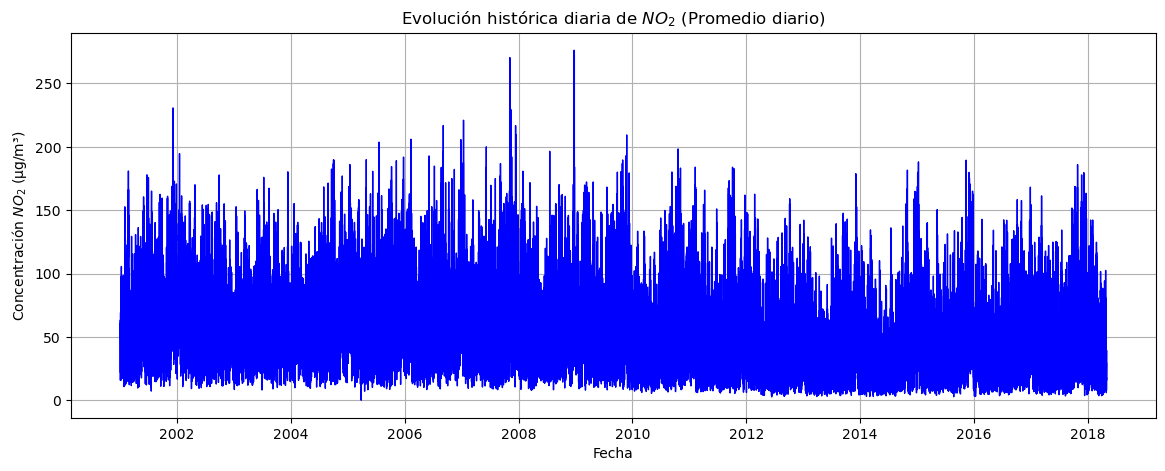

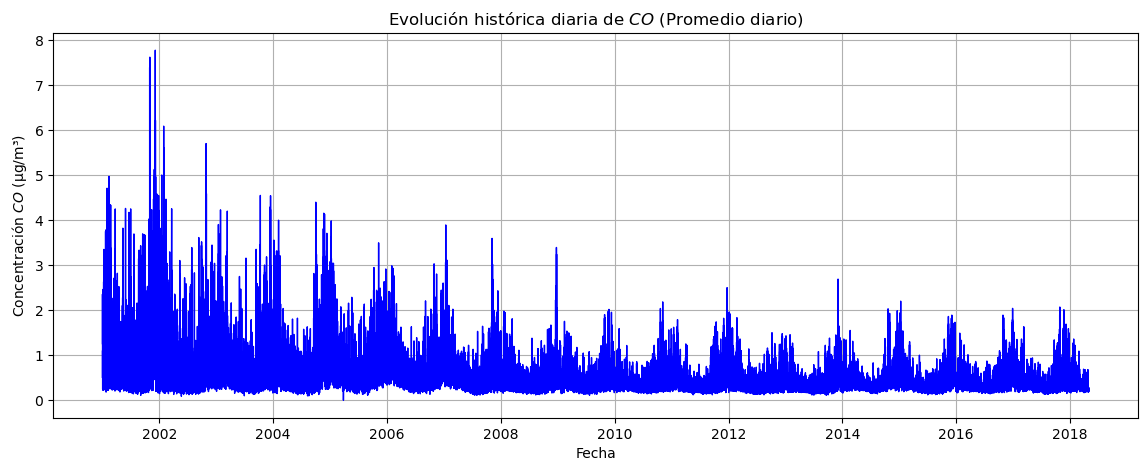

In [12]:
# =========================================
# GRÁFICOS DE SERIES TEMPORALES - NO2 y CO
# =========================================

# ---------------------------------
# Lista de contaminantes a graficar
# ---------------------------------
contaminantes = ['NO_2', 'CO']

# -----------------------------------
# Bucle para generar gráficos diarios
# -----------------------------------
for gas in contaminantes:
    if gas in df.columns:
        plt.figure(figsize=(14,5))
        plt.plot(df.index, df[gas], linewidth=1, color='blue')
        plt.title(f'Evolución histórica diaria de ${gas}$ (Promedio diario)')
        plt.xlabel('Fecha')
        plt.ylabel(f'Concentración ${gas}$ (µg/m³)')
        plt.grid(True)
        plt.show()

Veamnos el promedio mensual.

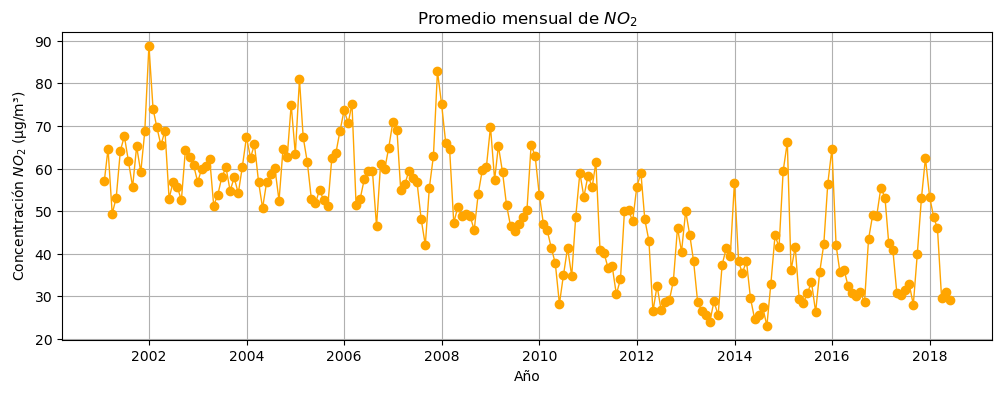

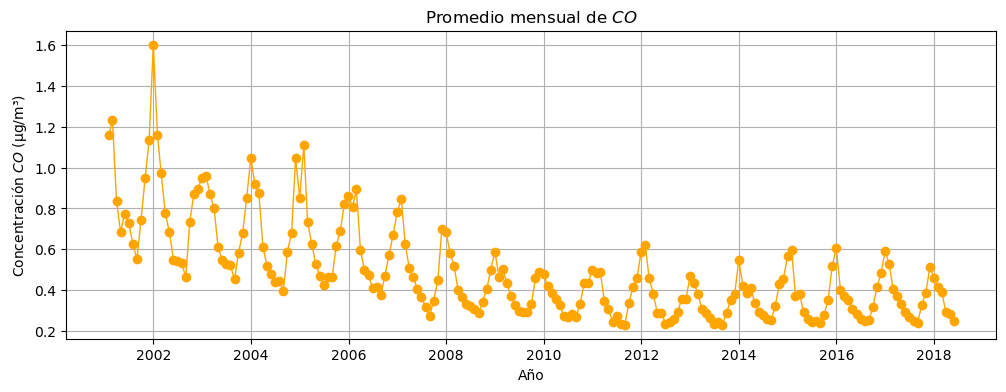

In [13]:
# ----------------------------------------
# Resampling mensual: promedio de cada mes
# 'ME' significa Month End (fin de mes)
# Esto reduce la serie diaria a valores mensuales
# ----------------------------------------
df_monthly = df[contaminantes].resample('ME').mean()

# --------------------------------
# GRÁFICO MENSUAL CON AMBOS GASES
# --------------------------------
for gas in contaminantes:
    if gas in df_monthly.columns:
        plt.figure(figsize=(12,4))
        plt.plot(df_monthly.index, df_monthly[gas], marker='o', linewidth=1, color='orange')
        plt.title(f'Promedio mensual de ${gas}$')
        plt.xlabel('Año')
        plt.ylabel(f'Concentración ${gas}$ (µg/m³)')
        plt.grid(True)
        plt.show()

Por último, el promedio anual.

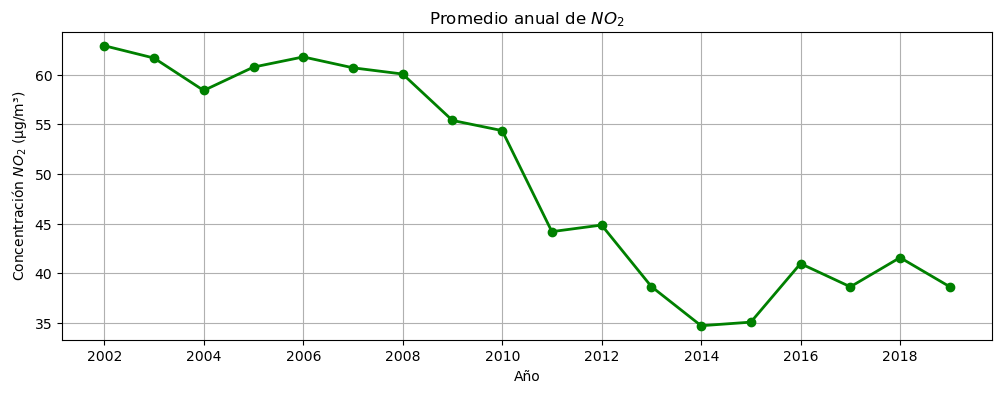

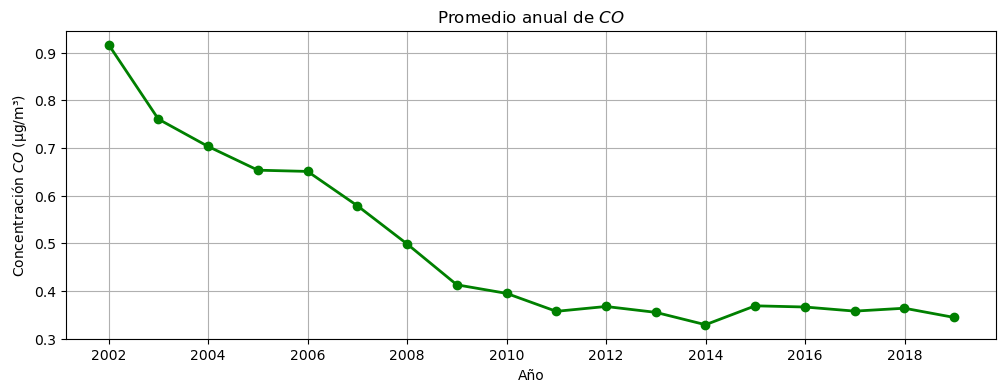

In [14]:
# ---------------------------
# Resampling anual: promedio de cada año
# 'YE' significa Year End (fin de año)
# Esto reduce la serie diaria a valores anuales
# ---------------------------
df_yearly = df[contaminantes].resample('YE').mean()

# ------------------------------
# GRÁFICO ANUAL CON AMBOS GASES
# ------------------------------
for gas in contaminantes:
    if gas in df_yearly.columns:
        plt.figure(figsize=(12,4))
        plt.plot(df_yearly.index, df_yearly[gas], marker='o', linewidth=2, color='green')
        plt.title(f'Promedio anual de ${gas}$')
        plt.xlabel('Año')
        plt.ylabel(f'Concentración ${gas}$ (µg/m³)')
        plt.grid(True)
        plt.show()

#### Descomposición de series temporales para NO₂ y CO en Madrid (2001-2018)
1️. Estacionaridad
Recordemos que una serie temporal estacionaria es aquella cuyas propiedades estadísticas (media, varianza, autocovarianza) no cambian con el tiempo. Esto es fundamental porque muchos métodos de predicción, como ARIMA, suponen que la serie es aproximadamente estacionaria. No estacionariedad puede provenir de:
    * Componentes deterministas: tendencia o estacionalidad.
    * Componentes estocásticos: raíz unitaria (ej. caminata aleatoria con deriva).

Tests comunes:
    * ***Augmented Dickey-Fuller (ADF)***: hipótesis nula → la serie tiene raíz unitaria (no estacionaria). Si el estadístico < valor crítico o p < alfa, podemos rechazar la hipótesis nula.
    * ***KPSS***: hipótesis nula → la serie es estacionaria. Si estadístico > valor crítico o p < alfa, se rechaza la hipótesis nula.

***Interpretación combinada ADF + KPSS***: A continuación aplicamos descomposición aditiva y multiplicativa para $NO_2$ y $CO$. Empecemos con el gas $NO_2$.

| KPSS            | ADF             | Interpretación                                                                     |
| --------------- | --------------- | ---------------------------------------------------------------------------------- |
| Estacionario    | No estacionario | Estacionaria en tendencia → eliminar tendencia para ser estrictamente estacionaria |
| No estacionario | Estacionario    | Estacionaria en diferencias → diferenciar la serie                                 |

#### Descomposición de series temporales

La descomposición de una serie temporal permite separar tres componentes principales:
$$
X_{t} = T_{t} + S_{t} + R_{t} (aditivo)
$$
o
$$
X_{t} = T_{t} \cdot S_{t} \cdot R_{t} (multiplicativo)
$$

Donde:
*  $T_{t}$: tendencia (cambio a largo plazo)
*  $S_{t}$: estacionalidad (variaciones periódicas, ej. horarias, diarias o anuales)
*  $R_{t}$: residual / ruido (aleatorio)

> * El tipo ***aditivo*** se usa cuando los componentes no dependen de la magnitud de la serie.
> * El tipo ***multiplicativo*** se usa cuando la variación estacional es proporcional al nivel de la serie.

<Figure size 1200x800 with 0 Axes>

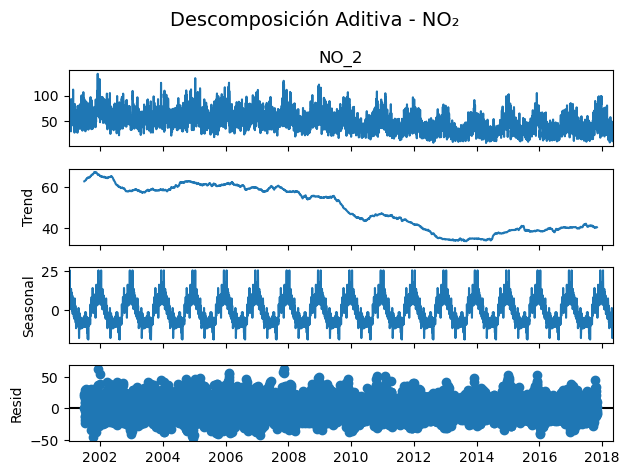

<Figure size 1200x800 with 0 Axes>

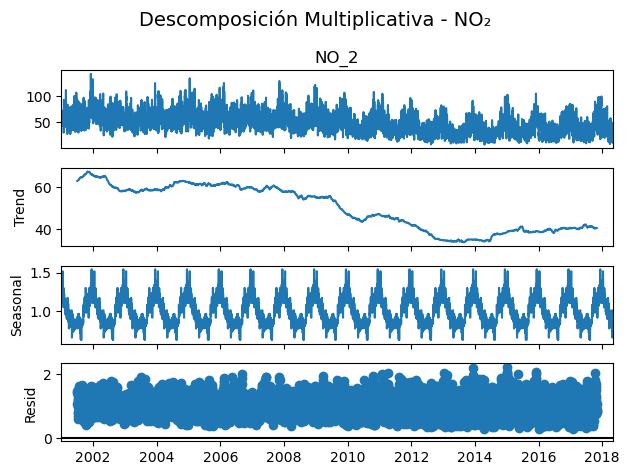

In [15]:
# -----------------------------------
# Seleccionamos los gases de interés
# -----------------------------------
gases = ['NO_2', 'CO']
df_gases = df[['NO_2', 'CO']].copy()

# Nos aseguramos que esté ordenado por tiempo
df_gases = df_gases.sort_index()

# -------------------------------------------
# Convertimos la serie a frecuencia diaria
# (Rellena faltantes con interpolación suave)
# -------------------------------------------
df_daily = df_gases.resample('D').mean().interpolate(method='linear')

# -----------------------
# DESCOMPOSICIÓN PARA NO₂
# -----------------------
result_no2_add = seasonal_decompose(df_daily['NO_2'], model='additive', period=365)
result_no2_mul = seasonal_decompose(df_daily['NO_2'], model='multiplicative', period=365)

# ==== Plot aditiva ====
plt.figure(figsize=(12,8))
result_no2_add.plot()
plt.suptitle('Descomposición Aditiva - NO₂', fontsize=14)
plt.tight_layout()
plt.show()

# ==== Plot multiplicativa ====
plt.figure(figsize=(12,8))
result_no2_mul.plot()
plt.suptitle('Descomposición Multiplicativa - NO₂', fontsize=14)
plt.tight_layout()
plt.show()

Ahora veamos para el gas CO.

<Figure size 1200x800 with 0 Axes>

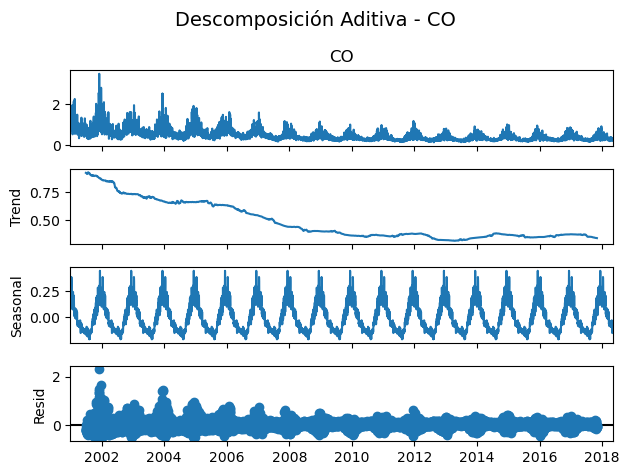

<Figure size 1200x800 with 0 Axes>

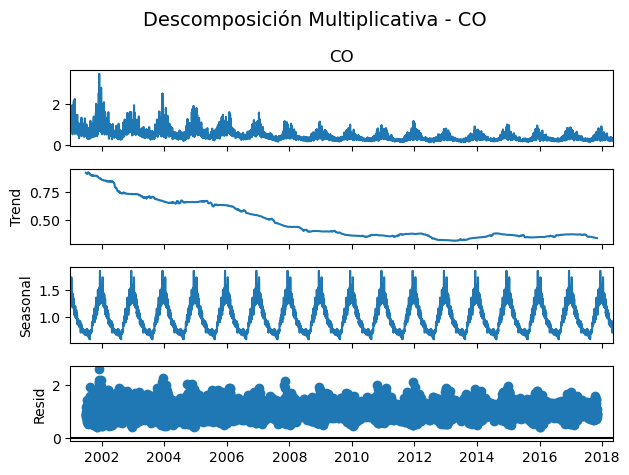

In [16]:
# -----------------------
# DESCOMPOSICIÓN PARA CO
# -----------------------
result_co_add = seasonal_decompose(df_daily['CO'], model='additive', period=365)
result_co_mul = seasonal_decompose(df_daily['CO'], model='multiplicative', period=365)

# ==== Plot aditiva ====
plt.figure(figsize=(12,8))
result_co_add.plot()
plt.suptitle('Descomposición Aditiva - CO', fontsize=14)
plt.tight_layout()
plt.show()

# ==== Plot multiplicativa ====
plt.figure(figsize=(12,8))
result_co_mul.plot()
plt.suptitle('Descomposición Multiplicativa - CO', fontsize=14)
plt.tight_layout()
plt.show()

La descomposición separa la serie en:
* ***Tendencia***: evolución lenta a lo largo de los años
* ***Estacionalidad***: patrón repetitivo anual
* ***Residuo***: variaciones no explicadas

***NO₂*** (dióxido de nitrógeno)

1. *Tendencia*: Se observa una disminución sostenida a lo largo de los años. Esto coincide con:
    * Renovación de flotas vehiculares
    * Implementación de zonas de baja emisión en Madrid
    * Regulación de combustibles → Interpretación: La calidad del aire mejoró en términos de NO₂.

2. *Estacionalidad*: El patrón anual es muy marcado:
    * Invierno: valores más altos (inversión térmica, más calefacción y tráfico lento)
    * Verano: valores más bajos (mejor dispersión atmosférica)

> Esto es típico de contaminantes relacionados al tránsito y combustión urbana.

3. *Aditiva vs multiplicativa*
    * La multiplicativa capta mejor la realidad, porque el tamaño de la estacionalidad cambia en función del nivel general.
    * La aditiva lo fuerza a ser constante, lo cual no es tan realista para NO₂.

***CO*** (monóxido de carbono)

1. *Tendencia*: También muestra una disminución sostenida, incluso más pronunciada que en NO₂. Esto se explica porque:
    * Nuevas normativas Euro en automóviles redujeron drásticamente las emisiones de CO.
    * Se redujo el uso de combustibles con mala combustión.
2. *Estacionalidad*: La estacionalidad en CO es más suave, pero aún se ve:
    * Invierno más alto
    * Verano más bajo

> La magnitud relativa es menor comparada con NO₂ → señal de fuentes más diversas y mejor control tecnológico.

3. Aditiva vs multiplicativa
    * Para CO, la aditiva funciona mejor porque la variación estacional es más constante en el tiempo.

***Conclusión***
* Ambos gases muestran una clara tendencia descendente entre 2001 y 2018, indicando mejora en la calidad del aire de Madrid, principalmente asociada a regulaciones del transporte.
* La estacionalidad del NO₂ es fuerte y multiplicativa, ligada a tráfico y condiciones atmosféricas en invierno.
* La estacionalidad del CO es más suave y aditiva, reflejando emisiones más uniformes y mayor eficiencia tecnológica.
* La reducción en ambos contaminantes sugiere políticas ambientales efectivas, especialmente en transporte y combustión urbana.

#### Próximos pasos para modelado:
* Transformación Box-Cox (log, raíz cuadrada, recíproca) para estabilizar varianza.
* Diferenciación para eliminar tendencia y estacionalidad.
* Test ADF y KPSS para confirmar estacionaridad antes de aplicar ARIMA o SARIMA.

Entonces, definimos las funciones necesarias

In [17]:
def test_adf(series, signif=0.05):
    """
    Función que realiza el test Augmented Dickey-Fuller (ADF)
    - series: Serie temporal a evaluar
    - signif: Nivel de significancia (default 5%)
    
    Retorna:
    - adf_stat: Estadístico de prueba ADF
    - p_value: Valor p
    - is_stationary: True si serie es estacionaria, False si no lo es
    """
    # Realiza la prueba ADF usando criterio AIC para elegir automáticamente el número de lags
    result = adfuller(series, autolag='AIC')
    adf_stat, p_value, used_lag, n_obs, crit_vals, icbest = result
    
    # Evaluamos si el p-value indica estacionaridad (p < alfa)
    is_stationary = p_value < signif
    return adf_stat, p_value, is_stationary

def test_kpss(series, signif=0.05, regression='c'):
    """
    Función que realiza el test KPSS
    - series: Serie temporal a evaluar
    - signif: Nivel de significancia (default 5%)
    - regression: 'c' para estacionaridad alrededor de la media, 'ct' para estacionaridad alrededor de tendencia
    
    Retorna:
    - statistic: Estadístico de prueba KPSS
    - p_value: Valor p
    - is_stationary: True si serie es estacionaria, False si no lo es
    """
    # Realiza la prueba KPSS. nlags="auto" deja que statsmodels elija el número de lags óptimo
    statistic, p_value, n_lags, crit_vals = kpss(series, regression=regression, nlags="auto")
    
    # En KPSS, p >= signif indica que la serie es estacionaria
    is_stationary = p_value >= signif
    return statistic, p_value, is_stationary

Recordemos que cada test mide:

| Test     | Hipótesis nula ($H_0$)                                     | Qué significa rechazar $H_0$                       | Qué significa NO rechazar $H_0$    |
| -------- | ------------------------------------------------------- | ----------------------------------------------- | ------------------------------- |
| **ADF**  | La serie **tiene raíz unitaria** → **no estacionaria**  | La serie **es estacionaria**                    | La serie **no es estacionaria** |
| **KPSS** | La serie **es estacionaria** alrededor de una tendencia | La serie **NO es estacionaria** (hay tendencia) | La serie **es estacionaria**    |

A continuación, calculamos los test de ADF y KPSS para cada gas. Además, generamos un resumen interpretativo automático.

In [18]:
# ===========================
# Loop para analizar cada gas
# ===========================
for gas in gases:
    print(f"\n\n================= {gas} =================")  # Encabezado para separar resultados de cada gas
    
    # -----------------------------------------------
    # Serie temporal diaria
    # Resample: agrupamos por día y sacamos promedio diario
    # Esto ayuda a reducir el ruido horario y facilita análisis de tendencias y estacionalidad
    # dropna(): eliminamos valores faltantes
    # -----------------------------------------------
    ts = df_gases[gas].resample('D').mean().dropna()
    
    # -----------------------------------------------
    # Test de estacionaridad
    # Aplicamos ADF y KPSS para evaluar si la serie es estacionaria
    # -----------------------------------------------
    adf_stat, adf_p, adf_stationary = test_adf(ts)      # Test Augmented Dickey-Fuller
    kpss_stat, kpss_p, kpss_stationary = test_kpss(ts)  # Test KPSS
    
    # Mostramos resultados de los tests
    print(f"\n--- Test de estacionaridad ---")
    print(f"ADF: estadístico={adf_stat:.3f}, p={adf_p:.3f}, estacionaria={adf_stationary}")
    print(f"KPSS: estadístico={kpss_stat:.3f}, p={kpss_p:.3f}, estacionaria={kpss_stationary}")
    
    # -----------------------------------------------
    # Interpretación automática combinando resultados ADF y KPSS
    # Dependiendo de los resultados, podemos clasificar la serie como:
    #   - estacionaria
    #   - no estacionaria (requiere transformación o diferenciación)
    #   - estacionaria en diferencia (tiene tendencia)
    #   - estacionaria en tendencia (eliminar tendencia para modelar)
    # -----------------------------------------------
    print("\n--- Interpretación ---")
    if adf_stationary and kpss_stationary:
        print("La serie es estacionaria.")
    elif not adf_stationary and not kpss_stationary:
        print("La serie no es estacionaria; requiere transformación o diferenciación.")
    elif adf_stationary and not kpss_stationary:
        print("La serie es estacionaria en diferencia (puede tener tendencia).")
    elif not adf_stationary and kpss_stationary:
        print("La serie es estacionaria en tendencia; se recomienda eliminar tendencia para modelar.")
    
    print("-" * 70)  # Línea divisoria entre gases



================= NO_2 =================

--- Test de estacionaridad ---
ADF: estadístico=-4.784, p=0.000, estacionaria=True
KPSS: estadístico=7.876, p=0.010, estacionaria=False

--- Interpretación ---
La serie es estacionaria en diferencia (puede tener tendencia).
----------------------------------------------------------------------


================= CO =================

--- Test de estacionaridad ---
ADF: estadístico=-4.556, p=0.000, estacionaria=True
KPSS: estadístico=7.027, p=0.010, estacionaria=False

--- Interpretación ---
La serie es estacionaria en diferencia (puede tener tendencia).
----------------------------------------------------------------------


Ya tenemos los resultados de los tests y la interpretación automática. Ahora debemos explicar qué significa ese resultado para $NO_2$ y $CO$ en Madrid entre 2001 y 2018. Primero recordamos qué dicen los tests:

* ***ADF (Augmented Dickey-Fuller)***: si el p-value es bajo (< 0.05) → sugiere estacionaridad.
* ***KPSS***: si el p-value es bajo (< 0.05) → sugiere no estacionaridad (hay tendencia o nivel no constante).

Los resultados muestran:

| Gas | ADF (p<0.05) | KPSS (p<0.05)   | Conclusión      |
| --- | ------------ | --------------- | --------------- |
| NO₂ | Estacionaria | No estacionaria | Tiene tendencia |
| CO  | Estacionaria | No estacionaria | Tiene tendencia |

Esto de hecho es un clásico caso contradictorio ADF vs KPSS, pero se interpreta así:

***Interpretación conceptual***

Cuando:
    * ADF dice estacionaria
    * KPSS dice no estacionaria

La serie ***no es estacionaria en nivel***, sino que ***es estacionaria en diferencia***.

Esto significa:

* La ***variabilidad*** del gas a lo largo del tiempo no cambia demasiado
* Pero la ***tendencia*** (el promedio a largo plazo) sí cambia a lo largo de los años

> La serie muestra una tendencia descendente o ascendente, pero alrededor de esa tendencia la variación es estable.

***Qué implica para $NO_2$ y $CO$ específicamente***

$NO_2$ (Dióxido de Nitrógeno)
* Proviene principalmente del tráfico.
* La descomposición seguramente mostró:
    * Tendencia descendente a lo largo de los años (debido a normativas EURO, restricciones de tráfico, etc.).
    * Estacionalidad anual clara: más NO₂ en invierno y menos en verano.

Por eso KPSS detecta tendencia.

$CO$ (Monóxido de Carbono)
* También tiene origen principalmente vehicular y combustión.
* También presenta:
    * Tendencia descendente (mejora tecnológica y leyes ambientales).
    * Ciclo estacional menos marcado que NO₂, pero igualmente más alto en meses fríos.

También no es estacionaria, pero se vuelve estacionaria si se le toma primera diferencia.

#### Conclusión Final

Las series temporales de $NO_2$ y $CO$ presentan un comportamiento similar en términos de estacionaridad. El test ADF indica estacionaridad, mientras que el test KPSS rechaza la hipótesis de estacionaridad, lo que implica que ambas series son estacionarias únicamente en diferencia, es decir, presentan tendencia a largo plazo. En ambos contaminantes se observa una tendencia descendente a lo largo del periodo 2001-2018, posiblemente asociada a políticas de control de emisiones, mejoras tecnológicas en vehículos y restricciones de circulación. Además, se aprecia estacionalidad anual, con valores más altos en meses fríos y menores en meses cálidos. Por lo tanto, para fines de modelado (por ejemplo, ARIMA), será necesario aplicar diferenciación (d=1) o eliminar la tendencia previamente.

Entonces, vamos a:
* Aplicar diferenciación (para remover tendencia).
* Aplicar transformación Box-Cox (para estabilizar varianza).
* Volver a testear estacionaridad con ADF y KPSS.

| Paso                           | Acción                  | Qué corrige                           |
| ------------------------------ | ----------------------- | ------------------------------------- |
| Box-Cox                        | Estabiliza la varianza  | Estacionalidad o cambios bruscos      |
| Diferenciación                 | Quita tendencia         | Raíces unitarias / no estacionariedad |
| ADF / KPSS post-transformación | Verifica estacionaridad | Nos dice si ya podemos modelar        |



================= $NO_2$ =================
Transformación Box-Cox aplicada con λ = 0.489

--- Test después de diferenciación ---
ADF: estadístico=-19.938, p=0.0000, estacionaria=True
KPSS: estadístico=0.017, p=0.1000, estacionaria=True

--- Nueva interpretación ---
La serie ahora es estacionaria. Ya se puede modelar (ARIMA, SARIMA, etc.).


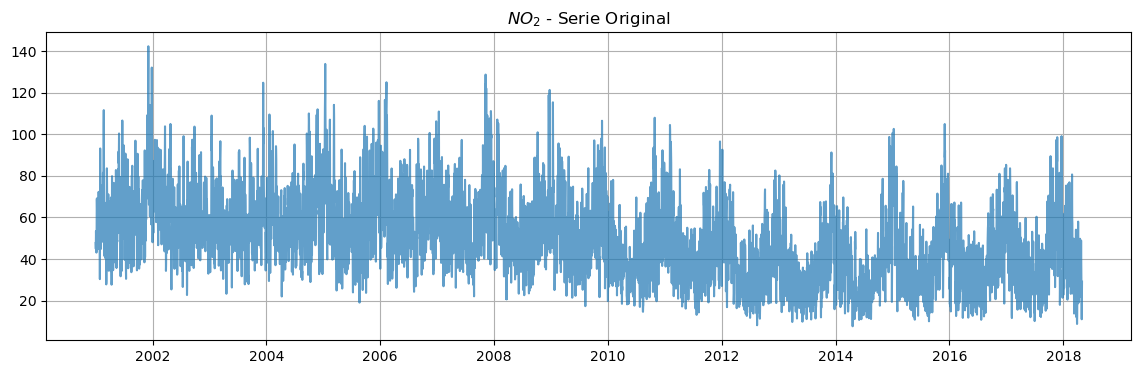

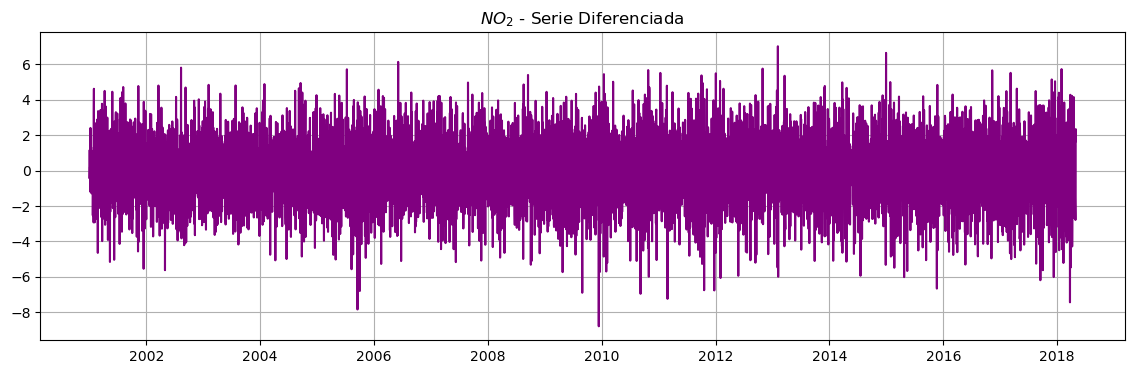

------------------------------------------------------------


================= $CO$ =================
Transformación Box-Cox aplicada con λ = -0.572

--- Test después de diferenciación ---
ADF: estadístico=-18.076, p=0.0000, estacionaria=True
KPSS: estadístico=0.050, p=0.1000, estacionaria=True

--- Nueva interpretación ---
La serie ahora es estacionaria. Ya se puede modelar (ARIMA, SARIMA, etc.).


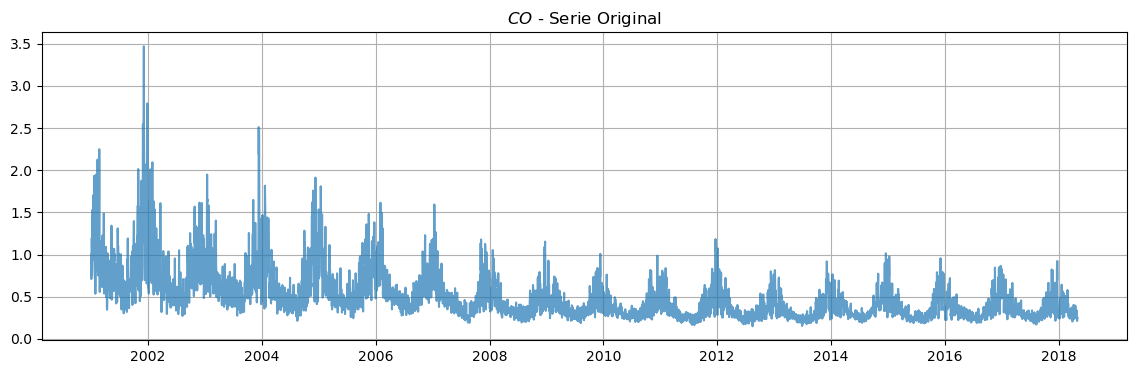

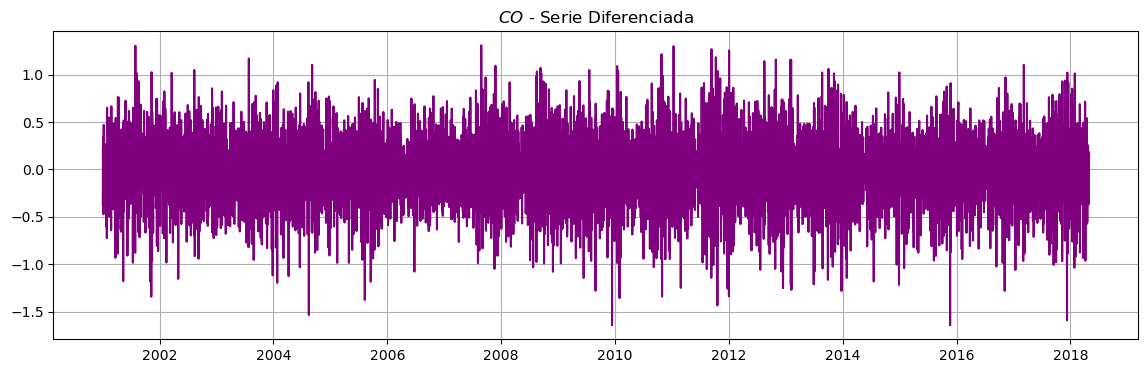

------------------------------------------------------------


In [19]:
# ------------------------------------------
# Aplicación de transformación + diferencias
# ------------------------------------------
for gas in gases:
    print(f"\n\n================= ${gas}$ =================")

    # Serie diaria
    ts = df[gas].resample('D').mean().dropna()

    # ------------------------------------------------------------------
    # 1) Transformación Box-Cox para estabilizar varianza
    # (solo se puede aplicar si toda la serie es > 0)
    # ------------------------------------------------------------------
    ts_bc = ts.copy()
    if (ts > 0).all():
        ts_bc, lambda_bc = boxcox(ts)
        ts_bc = pd.Series(ts_bc, index=ts.index)
        print(f"Transformación Box-Cox aplicada con λ = {lambda_bc:.3f}")
    else:
        print("La serie contiene ceros o valores negativos. Se omite Box-Cox.")
        ts_bc = ts.copy()

    # ------------------------------------------------------------------
    # 2) Diferenciación (orden 1)
    # ------------------------------------------------------------------
    ts_diff = ts_bc.diff().dropna()

    # ------------------------------------------------------------------
    # 3) Retesteo después de correcciones
    # ------------------------------------------------------------------
    adf_stat, adf_p, adf_stationary = test_adf(ts_diff)
    kpss_stat, kpss_p, kpss_stationary = test_kpss(ts_diff)

    print(f"\n--- Test después de diferenciación ---")
    print(f"ADF: estadístico={adf_stat:.3f}, p={adf_p:.4f}, estacionaria={adf_stationary}")
    print(f"KPSS: estadístico={kpss_stat:.3f}, p={kpss_p:.4f}, estacionaria={kpss_stationary}")

    # ------------------------------------------------------------------
    # 4) Interpretación automática
    # ------------------------------------------------------------------
    print("\n--- Nueva interpretación ---")
    if adf_stationary and kpss_stationary:
        print("La serie ahora es estacionaria. Ya se puede modelar (ARIMA, SARIMA, etc.).")
    else:
        print(" Aún no es completamente estacionaria. Se recomienda diferenciar nuevamente o ajustar modelo SARIMA.")

    # ------------------------------------------------------------------
    # 5) Graficar antes / después
    # ------------------------------------------------------------------
    plt.figure(figsize=(14,4))
    plt.plot(ts, label='Original', alpha=0.7)
    plt.title(f"${gas}$ - Serie Original")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14,4))
    plt.plot(ts_diff, label='Diferenciada (y Box-Cox si aplicó)', color='purple')
    plt.title(f"${gas}$ - Serie Diferenciada")
    plt.grid(True)
    plt.show()

    print("-" * 60)

#### Resultados originales (sin transformación/diferenciación)

| Gas | ADF estadístico | ADF p-value | ADF estacionaria | KPSS estadístico | KPSS p-value | KPSS estacionaria | Interpretación                                     |
| --- | --------------- | ----------- | ---------------- | ---------------- | ------------ | ----------------- | -------------------------------------------------- |
| NO₂ | -4.784          | 0.000       | True             | 7.876            | 0.010        | False             | Estacionaria en diferencia (puede tener tendencia) |
| CO  | -4.556          | 0.000       | True             | 7.027            | 0.010        | False             | Estacionaria en diferencia (puede tener tendencia) |

#### Resultados después de Box-Cox y diferenciación

| Gas | λ Box-Cox | ADF estadístico | ADF p-value | ADF estacionaria | KPSS estadístico | KPSS p-value | KPSS estacionaria | Interpretación                                                     |
| --- | --------- | --------------- | ----------- | ---------------- | ---------------- | ------------ | ----------------- | ------------------------------------------------------------------ |
| NO₂ | 0.489     | -19.938         | 0.0000      | True             | 0.017            | 0.1000       | True              | Ahora la serie es estacionaria, lista para modelado ARIMA/SARIMA |
| CO  | -0.572    | -18.076         | 0.0000      | True             | 0.050            | 0.1000       | True              | Ahora la serie es estacionaria, lista para modelado ARIMA/SARIMA |

#### Comparación visual y conceptual

| Aspecto                   | Antes de transformación        | Después de Box-Cox + Diferenciación |
| ------------------------- | ------------------------------ | ----------------------------------- |
| Varianza                  | Variable, crece con el tiempo  | Más estable                         |
| Tendencia                 | Presente, visible              | Eliminada con diferenciación        |
| Estacionalidad            | Presente                       | Parcialmente eliminada en residuo   |
| Estacionaridad ADF        | Sí, estacionaria en diferencia | Sí, completamente estacionaria      |
| Estacionaridad KPSS       | No                             | Sí                                  |
| Preparación para modelado | No                             | Sí, lista para ARIMA/SARIMA         |

Tanto $NO_2$ como $CO$:

1. Permitieron aplicar Box-Cox: Eso significa que no había ceros ni valores negativos en las series.
Además, la transformación Box-Cox suavizó la varianza, lo cual ayuda a estabilizar el comportamiento estadístico de la serie.

Los valores de $\lambda$:
    * $\lambda$ ≈ 0.489 para NO₂ → transformación casi raíz cuadrada.
    * $\lambda$ ≈ -0.572 para CO → transformación cercana a log inverso.

Esto simplemente refleja que cada contaminante tiene distinta escala y distribución, y la transformación lo ajusta.

2. Luego le aplicamos diferenciación de orden 1. La diferenciación elimina la tendencia y deja las fluctuaciones locales más claras.
3. Ambos tests dicen que ahora la serie es estacionaria
    * ADF rechaza la hipótesis de raíz unitaria → tiende a ser estacionaria.
    * KPSS ahora no rechaza la hipótesis de estacionariedad → no hay tendencia remanente.

Conclusión:
> La serie quedó estacionaria después de Box-Cox + Differencing(1).

***¿Qué significa esto en práctica?***

Ahora tus series $NO_2$ como $CO$ están listas para modelarse. Es decir:
* Podemos usar ARIMA(p,1,q) (con d=1 porque ya diferenciamos).
* O SARIMA(p,1,q)(P,D,Q)s si se desea capturar estacionalidad (por ejemplo mensual o diaria).

#### Resumen

Las series originales de $NO_2$ como $CO$ mostraban no-estacionariedad, con tendencia y posible heterocedasticidad. Al aplicar una transformación Box-Cox seguida de una diferenciación de primer orden, ambas series pasaron a ser estacionarias según los tests ADF y KPSS (ADF: p < 0.01, KPSS: p > 0.05). Esto confirma que la combinación de transformación de varianza y eliminación de tendencia fue efectiva. Por lo tanto, estas series ya se encuentran en condiciones adecuadas para modelación mediante ARIMA/SARIMA u otros métodos que requieren estacionariedad.

## 3. Modelado de series temporales <a name="series2"></a>

Si bien ***estacionariedad*** y ***estacionalidad*** suenan parecidas, pero en análisis de series temporales son conceptos muy diferentes y complementarios.

1. ***Serie Estacionaria***

Una serie temporal estacionaria es aquella cuyas propiedades estadísticas (media, varianza y covarianza) no cambian en el tiempo. En otras palabras, su comportamiento estadístico es estable. Formalmente, una serie $\{Y_t\}$ es **débilmente estacionaria** (o de segundo orden) si cumple:

$$
\begin{cases}
E[Y_t] = \mu, & \text{(la media es constante en el tiempo)} \\
Var(Y_t) = \sigma^2, & \text{(la varianza es constante en el tiempo)} \\
Cov(Y_t, Y_{t-k}) = \gamma(k), & \text{(la covarianza depende solo del rezago \(k\), no del tiempo \(t\))}
\end{cases}
$$

Intuición:

- No hay **tendencia** (la serie no crece ni decrece sistemáticamente).  
- No hay **cambios de varianza** (no hay periodos de alta/baja volatilidad).  
- La **estructura de correlaciones** se mantiene estable.

Ejemplo:

Una serie estacionaria podría parecer una línea “serruchada” alrededor de un valor constante:

$$
Y_t = 5 + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)
$$

1. ***Estacionalidad***

La estacionalidad ocurre cuando la serie repite patrones o fluctuaciones regulares a intervalos fijos de tiempo (por ejemplo, cada año, mes o semana).

La **estacionalidad** ocurre cuando la serie **repite patrones o fluctuaciones regulares** a intervalos fijos de tiempo (por ejemplo, cada año, mes o semana).

$$
Y_t = f(t \bmod s) + \varepsilon_t
$$

donde:

- $s$ es el **período estacional** (por ejemplo, 12 para meses en un año).  
- $f(t \bmod s)$ representa el **patrón que se repite**.

Intuición:

- La estacionalidad **no implica** que la serie sea estacionaria.  
- Una serie **puede ser no estacionaria pero estacional**, si los patrones cambian con el tiempo (por ejemplo, si la amplitud aumenta).

Ejemplo:

Temperaturas promedio mensuales:

$$
Y_t = 20 + 10 \cdot \sin\left(\frac{2\pi t}{12}\right) + \varepsilon_t
$$

Aquí hay un patrón **anual (12 meses)**, pero la serie podría no ser estacionaria si la media o la amplitud cambian con el tiempo.

***Diferencias Clave***

| Característica       | **Estacionariedad**                              | **Estacionalidad**                                    |
| -------------------- | ------------------------------------------------ | ----------------------------------------------------- |
| **Definición**       | Propiedades estadísticas constantes en el tiempo | Patrón periódico que se repite regularmente           |
| **Causa**            | Ausencia de tendencia o cambio estructural       | Ciclos naturales o de calendario                      |
| **Ejemplo típico**   | Ruido blanco o $AR(1)$ estable                     | Temperatura, ventas mensuales, consumo eléctrico      |
| **Tratamiento**      | Diferenciación para remover tendencia            | Diferenciación estacional o descomposición estacional |
| **Símbolo en ARIMA** | Parámetro $d$ (diferenciación regular)         | Parámetro $D$ y periodo $m$ en $SARIMA$             |

***Relación con ARIMA y SARIMA***

- En **$ARIMA(p, d, q)$**  
  - $d$: número de **diferencias necesarias** para hacer la serie estacionaria (elimina la tendencia).  
- En **$SARIMA(p, d, q)(P, D, Q)_m$**  
  - $D$: número de **diferencias estacionales** necesarias para eliminar el patrón repetitivo.  
  - $m$: longitud del **ciclo estacional** (por ejemplo, 12 para meses o 52 para semanas).

***Ejemplo comparativo***

| Tipo de serie                   | Descripción                                           | Tratamiento típico                     |
| ------------------------------- | ----------------------------------------------------- | -------------------------------------- |
| **Tendencia (no estacionaria)** | La serie crece o decrece con el tiempo                | Diferenciar una vez $(d=1)$          |
| **Estacionalidad**              | Patrones regulares cada ( m ) períodos                | Diferenciar con rezago $m$ $( D=1 )$ |
| **Ambas**                       | Tendencia + patrones periódicos                       | Diferenciar regular y estacional       |
| **Estacionaria**                | Oscila alrededor de una media fija sin patrón visible | No requiere diferenciación             |

***Resumen***

- **Estacionariedad** → estabilidad estadística en el tiempo.  
- **Estacionalidad** → patrón repetitivo periódico.  
- Una serie puede ser:
  - Estacionaria **y no estacional** (ruido blanco).  
  - No estacionaria **y estacional** (temperatura mensual).  
  - No estacionaria **y no estacional** (tendencia creciente).  
  - Estacionaria **y estacional** (patrón estable y repetitivo sin cambio estructural).

#### ARIMA: Autoregressive Integrated Moving Average

ARIMA combina tres componentes y se denota como:

$$
\text{ARIMA}(p,d,q)
$$

donde:

- **p (autoregressive, AR):** número de términos autorregresivos. La serie depende de sus propios valores pasados.  

  **Ejemplo:**
  $$
  y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \varepsilon_t
  $$

- **d (integrated, I):** número de diferencias necesarias para hacer la serie estacionaria.  

  **Ejemplo:**
  $$
  d = 1 \quad \Rightarrow \quad y'_t = y_t - y_{t-1}
  $$

- **q (moving average, MA):** número de términos de media móvil. La serie depende de errores pasados.  

  **Ejemplo:**
  $$
  y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots
  $$

#### Cuándo usar ARIMA

- Series **estacionarias** (o convertidas a estacionarias mediante diferenciación)  
- Sin **estacionalidad** marcada (o estacionalidad ya removida)

#### Ventajas

- Buen rendimiento para series con **tendencia**  
- Base para modelos estacionales más complejos, como **SARIMA**

#### SARIMA: Seasonal ARIMA

SARIMA extiende ARIMA para manejar **series temporales estacionales**.  
Se denota como:

$$
\text{SARIMA}(p,d,q)(P,D,Q)_s
$$

donde:

- **p, d, q:** mismos que en ARIMA (AR, I, MA) para la parte no estacional.
- **P, D, Q:** componentes estacionales de AR, I, MA.
- **s:** longitud del período estacional (por ejemplo, 12 para datos mensuales con estacionalidad anual).

#### Componentes estacionales

1. **P (autoregressive estacional, SAR):**  
   Número de términos autorregresivos sobre períodos pasados de la estacionalidad.  
   $$
   y_t = \Phi_1 y_{t-s} + \Phi_2 y_{t-2s} + \dots + \varepsilon_t
   $$

2. **D (integrated estacional, SI):**  
   Número de diferencias estacionales necesarias para estabilizar la serie en términos de su componente estacional.  
   $$
   D=1 \quad \Rightarrow \quad y'_t = y_t - y_{t-s}
   $$

3. **Q (moving average estacional, SMA):**  
   Número de términos de media móvil sobre los errores estacionales pasados.  
   $$
   y_t = \varepsilon_t + \Theta_1 \varepsilon_{t-s} + \Theta_2 \varepsilon_{t-2s} + \dots
   $$

#### Cuándo usar SARIMA

- Series con **estacionalidad marcada**  
- Series que muestran **tendencia y estacionalidad** simultáneamente  
- Cuando ARIMA simple no captura los patrones repetitivos periódicos

#### Ventajas

- Permite modelar series con **tendencia + estacionalidad**  
- Mantiene la flexibilidad de ARIMA en la parte no estacional  
- Muy útil para **pronósticos de series temporales con ciclos periódicos**

En lo que sigue vamos a implementar ARIMA. Primero, determinamos los parámetros generales:

In [20]:
# =====================
# PARÁMETROS GENERALES
# =====================
gas = 'NO_2'              # Variable a modelar
n_jobs = -1               # Usar todos los núcleos disponibles para auto_arima
seasonal_lag = 365        # Lag estacional (diario -> 365 días)
fraction_train = 0.8      # Proporción de train / test
n_days_total = 6330       # Número total de días a tomar de la serie histórica

Luego, determinamos el número de días que deseamos utilizar en el ajuste del modelo.

In [21]:
# ==========================
# PREPARAR SERIES TEMPORALES
# ==========================
ts_full = df[gas].resample('D').mean().dropna()  # Promedio diario y eliminar NA

# Seleccionar últimos n_days_total días
ts_2y = ts_full.last(f"{n_days_total}D")
print(f"Total días: {len(ts_full)}")
print(f"Días seleccionados (últimos {n_days_total} días): {len(ts_2y)}")

Total días: 6330
Días seleccionados (últimos 6330 días): 6330


Ahora generamos el conjunto de datos de entrenamiento y testeo.

In [22]:
# ======================
# DIVISIÓN TRAIN / TEST
# ======================
n_total = len(ts_2y)
split_point = int(n_total * fraction_train)
train = ts_2y.iloc[:split_point].copy()
test  = ts_2y.iloc[split_point:].copy()

# Imprimo
print(f"Tamaño total: {n_total}")
print(f"Train: {len(train)} días ({len(train)/n_total*100:.2f}%)")
print(f"Test : {len(test)} días ({len(test)/n_total*100:.2f}%)")

Tamaño total: 6330
Train: 5064 días (80.00%)
Test : 1266 días (20.00%)


Controlemos gráficamente la elección de los conjuntos de datos.

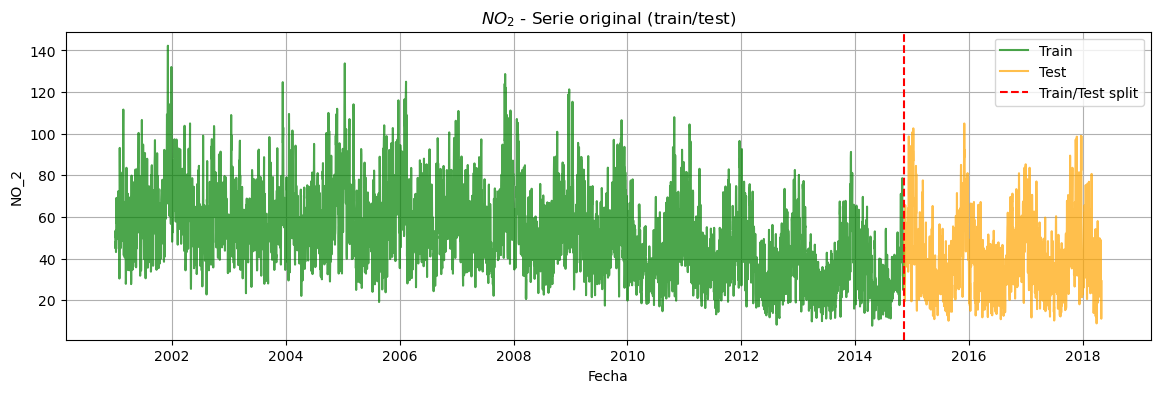

In [23]:
# ============================================================
# GRAFICAR SERIE ORIGINAL (Train y Test con colores distintos)
# ============================================================
plt.figure(figsize=(14,4))
plt.plot(train.index, train.values, label='Train', color='green', alpha=0.7)
plt.plot(test.index, test.values, label='Test', color='orange', alpha=0.7)
plt.axvline(train.index[-1], color='red', linestyle='--', label='Train/Test split')
plt.title(f"${gas}$ - Serie original (train/test)")
plt.xlabel("Fecha") 
plt.ylabel(gas)
plt.legend()
plt.grid(True)
plt.show()

Estamos en condiciones de aplicar Box-Cox para estabilizar la varianza a los datos de entrenamiento.

In [24]:
# =====================================================
# BOX-COX EN TRAIN (si todos los valores son positivos)
# =====================================================
use_boxcox = False
lambda_bc = None
train_bc = train.copy()  # Serie sobre la que trabajaremos

if (train > 0).all():
    # Aplicar Box-Cox para estabilizar varianza
    train_vals, lambda_bc = boxcox(train.values)
    train_bc = pd.Series(train_vals, index=train.index)
    use_boxcox = True
    print(f"Box-Cox aplicado sobre train. λ = {lambda_bc:.5f}")
else:
    print("Box-Cox omitido: existen ceros o valores negativos en train.")

Box-Cox aplicado sobre train. λ = 0.54797


Tal como hemos concluido en el análisis de la serie, debemos aplicar sobre la serie
- Diferenciación regular (orden 1),
- Diferenciación estacional.

In [25]:
# ======================
# DIFERENCIACIÓN MANUAL
# ======================
# (a) Diferencia regular (orden 1)
train_diff = train_bc.diff().dropna()
print(f"train_bc length: {len(train_bc)} -> train_diff length (after diff1): {len(train_diff)}")

# (b) Diferencia estacional
if len(train_diff) <= seasonal_lag:
    raise RuntimeError(f"Train demasiado corto para aplicar diferencia estacional lag={seasonal_lag}.")
train_both = train_diff.diff(seasonal_lag).dropna()
print(f"train_diff length: {len(train_diff)} -> train_both length (after seasonal diff): {len(train_both)}")

train_bc length: 5064 -> train_diff length (after diff1): 5063
train_diff length: 5063 -> train_both length (after seasonal diff): 4698


Controlemos graficamente el resultado de diferenciar la serie.

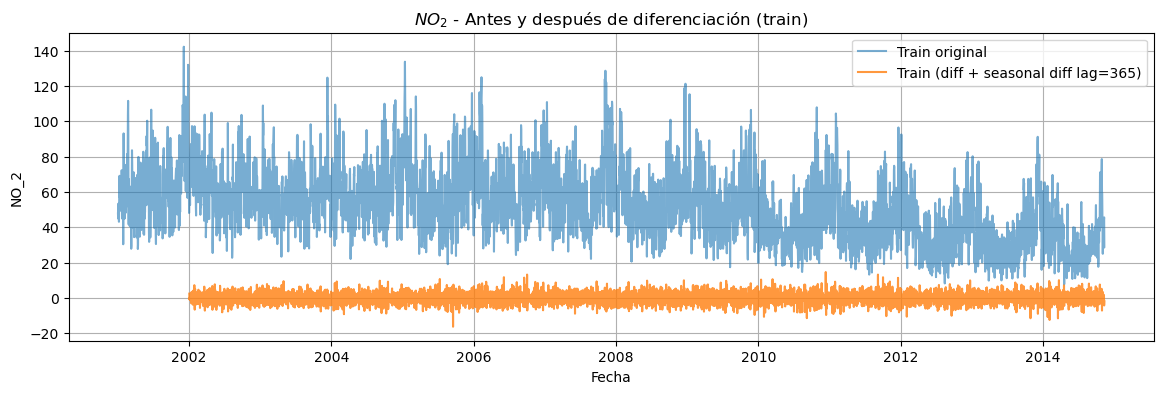

In [26]:
# ========================
# GRAFICAR DIFERENCIACIÓN
# ========================
plt.figure(figsize=(14,4))
plt.plot(train.index, train.values, label='Train original', alpha=0.6)
plt.plot(train_both.index, train_both.values, label=f'Train (diff + seasonal diff lag={seasonal_lag})', alpha=0.8)
plt.title(f"${gas}$ - Antes y después de diferenciación (train)")
plt.xlabel("Fecha")
plt.ylabel(gas)
plt.legend()
plt.grid(True)
plt.show()

En lo que sigue, estamos en condiciones de aplicar el modelo ARIMA mediante `auto_arima`. Luego, guardamos el modelo.

In [27]:
# ==============================================
# AJUSTAR auto_arima SOBRE LA SERIE DIFERENCIADA
# ==============================================
print("\n[A] Ajustando auto_arima sobre la serie diferenciada (seasonal=False, d=0)...")
auto_model = pm.auto_arima(
    train_both,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=0,                   # ya diferenciada
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    n_jobs=n_jobs,
    max_order=10
)
print("\nModelo ARIMA ajustado:")
print(auto_model.summary())

# Guardar modelo a disco
model_path = "auto_arima_no2_diff.pkl"
joblib.dump(auto_model, model_path)
print(f"Modelo guardado en: {model_path}")


[A] Ajustando auto_arima sobre la serie diferenciada (seasonal=False, d=0)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=24638.947, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=24584.688, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=24489.097, Time=0.20 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.63 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=23632.755, Time=0.47 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=23434.081, Time=0.71 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=23435.744, Time=1.46 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=23434.967, Time=1.41 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=23448.485, Time=0.70 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=23452.254, Time=0.81 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=23436.386, Time=3.07 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=23436.010, Time=2.31 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 11.978 seconds

M

Obtenido el modelo, podemos predecir los datos de la serie.

In [28]:
# =====================
# PRONOSTICO SOBRE TEST
# =====================
n_periods = len(test)
print(f"Generando pronóstico de {n_periods} pasos sobre la serie diferenciada...")

y_pred_diff, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)
yhat_diff = pd.Series(y_pred_diff, index=test.index)  # Series alineada con test

Generando pronóstico de 1266 pasos sobre la serie diferenciada...


Para continuar con el análisis, debemos tomar las predicciones del modelo (que fueron calculadas sobre datos transformados y diferenciados) y las debemos convertir nuevamente a la escala original del gas. Esto implica revertir dos transformaciones:
* La diferenciación manual estacional y/o simple, y
* La transformación Box-Cox (si fue aplicada).

In [29]:
# ================================
# RECONSTRUCCIÓN A ESCALA ORIGINAL
# ================================

# Copias de las series transformadas
train_diff_series = train_diff.copy()   # serie diferenciada (sin tendencia)
train_bc_series   = train_bc.copy()     # serie transformada con Box-Cox

# Listas donde guardaremos las predicciones paso a paso
pred_train_diff_vals = []   # predicciones en escala diferenciada
pred_train_bc_vals   = []   # predicciones en escala Box-Cox
pred_original_vals   = []   # predicciones en escala real

# Última fecha del conjunto de entrenamiento
last_train_date = train.index[-1]

# Bucle sobre cada paso de pronóstico
for step in range(n_periods):
    # Fecha del paso actual
    t = last_train_date + pd.Timedelta(days=(step + 1))

    # Fecha una estación atrás (para revertir diferenciación estacional)
    t_minus_s = t - pd.Timedelta(days=seasonal_lag)
    ref_val = train_diff_series.loc[t_minus_s]

    # Predicción del modelo ARIMA (en escala diferenciada)
    pred_train_both = yhat_diff.iloc[step]

    # Reconstrucción: revertir diferenciación estacional
    pred_train_diff = pred_train_both + ref_val

    # Guardar en la serie extendida
    train_diff_series.loc[t] = pred_train_diff
    pred_train_diff_vals.append(pred_train_diff)

    # Obtener valor anterior para revertir diferenciación simple
    t_minus_1 = t - pd.Timedelta(days=1)
    prev_train_bc = train_bc_series.loc[t_minus_1]

    # Reconstrucción en escala Box-Cox
    pred_train_bc = prev_train_bc + pred_train_diff
    train_bc_series.loc[t] = pred_train_bc
    pred_train_bc_vals.append(pred_train_bc)

    # Invertir transformación Box-Cox (si fue usada)
    if use_boxcox:
        pred_orig = inv_boxcox(pred_train_bc, lambda_bc)
    else:
        pred_orig = pred_train_bc

    # Guardar valor final reconstruido
    pred_original_vals.append(pred_orig)

# Convertir lista de predicciones a serie con índice temporal
y_pred_reconstructed = pd.Series(pred_original_vals, index=test.index)

Luego, definimos las métricas y las calculamos sobre las predicciones reconstruidas.

In [30]:
# ======================
# FUNCIONES DE MÉTRICAS
# ======================
def rmse(y_true, y_pred):
    """Raíz del error cuadrático medio."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    """MAPE: Mean Absolute Percentage Error (evita división por cero)."""
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

# ================================
# MÉTRICAS SOBRE EL CONJUNTO TEST
# ================================

# Cálculo de métricas
mae_val = mean_absolute_error(test.values, y_pred_reconstructed.values)
rmse_val = rmse(test.values, y_pred_reconstructed.values)
mape_val = mape(test.values, y_pred_reconstructed.values)

# Mostrar métricas con formato
print("Métricas sobre conjunto test (predicciones reconstruidas):")
print(f"MAE  = {mae_val:.3f}")
print(f"RMSE = {rmse_val:.3f}")
print(f"MAPE = {mape_val:.3f} %")

Métricas sobre conjunto test (predicciones reconstruidas):
MAE  = 15.893
RMSE = 20.226
MAPE = 41.855 %


Por último, una gráfica comparativa entre los datos predichos y los datos de validación.

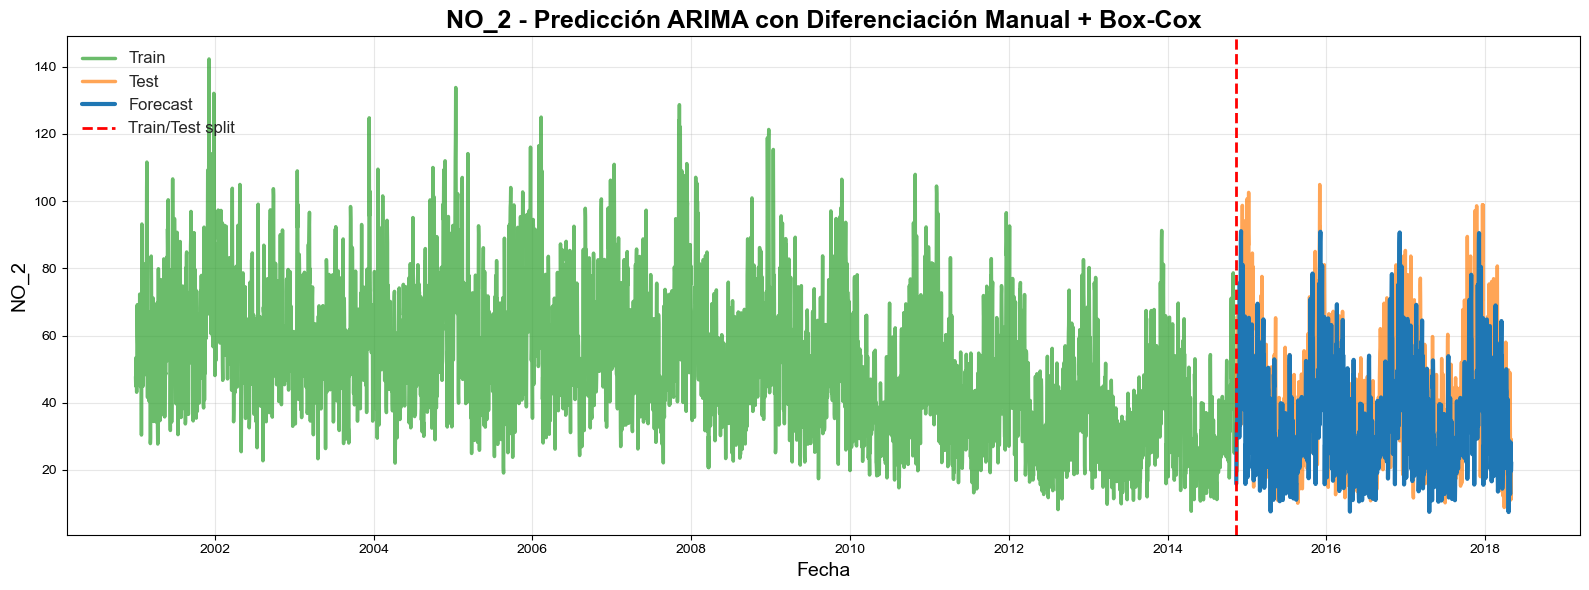

In [31]:
# ================================================================
# GRÁFICO FINAL: Train + Test + Forecast + Intervalo de confianza
# ================================================================

# Crear figura y ejes
fig, ax = plt.subplots(figsize=(16,6))
# - subplots devuelve (figura, eje). figsize controla el tamaño en pulgadas (ancho, alto).

# Establecer estilo limpio y profesional
plt.style.use('seaborn-v0_8-whitegrid')
# - Aplica un conjunto de parámetros gráficos (fondo blanco, cuadrícula suave).
# - Usamos la variante disponible en tu entorno: 'seaborn-v0_8-whitegrid'.

# -----------------------
# PLOTEAR TRAIN
# -----------------------
ax.plot(
    train.index,              # eje X: fechas de la serie de entrenamiento
    train.values,             # eje Y: valores del contaminante en train
    label='Train',            # etiqueta que aparecerá en la leyenda
    color='#2ca02c',          # color (verde suave)
    alpha=0.7,                # transparencia de la línea (0 = invisible, 1 = opaca)
    linewidth=2.5             # grosor de la línea
)
# - Este plot dibuja la serie de entrenamiento con estilo destacado para identificarla.

# -----------------------
# PLOTEAR TEST
# -----------------------
ax.plot(
    test.index,               # eje X: fechas de test
    test.values,              # eje Y: valores reales en test
    label='Test',             # etiqueta para la leyenda
    color='#ff7f0e',          # naranja para distinguir del train
    alpha=0.7,                # transparencia
    linewidth=2.5             # grosor
)
# - Distinguir train/test por color facilita la comparación visual.

# -----------------------
# PLOTEAR FORECAST / PREDICCIONES
# -----------------------
ax.plot(
    y_pred_reconstructed.index,  # eje X: fechas de las predicciones reconstruidas
    y_pred_reconstructed.values, # eje Y: valores predichos en escala original
    label='Forecast',            # etiqueta de la predicción
    color='#1f77b4',             # azul clásico para forecast
    linewidth=3                  # línea más gruesa para destacar la predicción
)
# - La predicción se dibuja más visible (línea más gruesa) que las series observadas.

# -----------------------
# INTERVALO DE CONFIANZA PREMIUM (SOMBREADO DEGRADADO)
# -----------------------
# Preparamos los límites inferior y superior del intervalo:
conf_lower = inv_boxcox(conf_int[:,0], lambda_bc) if use_boxcox else conf_int[:,0]
conf_upper = inv_boxcox(conf_int[:,1], lambda_bc) if use_boxcox else conf_int[:,1]
# - conf_int debe ser un array Nx2 con (lower, upper). Si aplicaste Box-Cox, lo invertimos.
# - Si no usaste Box-Cox, usamos los límites tal cual.
# - IMPORTANTE: conf_int debe tener la misma longitud y alineación temporal que `test`.

# Normalizamos alpha (más claro hacia el futuro) para simular incertidumbre creciente
alphas = np.linspace(0.6, 0.1, len(test))
# - Crea una secuencia de opacidades desde 0.6 (cerca) a 0.1 (más adelante).
# - len(test) determina cuántos segmentos vamos a dibujar.

# Rellenamos el área en pequeños segmentos (pares de puntos) para poder aplicar distinto alpha por tramo
for i in range(len(test)-1):
    # rellenamos entre cada par de fechas consecutivas con un alpha local
    ax.fill_between(
        test.index[i:i+2],         # dos fechas consecutivas (segmento del eje x)
        conf_lower[i:i+2],         # límite inferior para ese segmento
        conf_upper[i:i+2],         # límite superior para ese segmento
        color='#aec7e8',           # color base del sombreado (azul claro)
        alpha=alphas[i]            # opacidad local (decreciente con i)
    )
# - Este bucle produce un sombreado que se va haciendo más tenue hacia la derecha (incertidumbre creciente).
# - Alternativa: hacer un solo fill_between con alpha constante, pero así el efecto degradado es más vistoso.

# -----------------------
# LÍNEA DE DIVISIÓN TRAIN/TEST
# -----------------------
ax.axvline(
    train.index[-1],    # posición x de la última fecha de train (splitting point)
    color='red',        # color rojo para destacar el corte
    linestyle='--',     # línea discontinua
    linewidth=2,        # grosor
    label='Train/Test split'
)
# - Marca visualmente el punto donde termina el conjunto de entrenamiento.

# -----------------------
# TÍTULOS Y ETIQUETAS
# -----------------------
ax.set_title(
    f"{gas} - Predicción ARIMA con Diferenciación Manual + Box-Cox",
    fontsize=18, weight='bold'
)
# - Título grande y en negrita para presentación.
ax.set_xlabel("Fecha", fontsize=14)
ax.set_ylabel(f"{gas}", fontsize=14)
# - Etiquetas de ejes con tamaño adecuado para figura amplia.

# -----------------------
# FORMATO DE FECHAS PREMIUM
# -----------------------
locator = mdates.AutoDateLocator()
# - AutoDateLocator elige automáticamente ubicaciones de ticks (meses, años, días) según rango.
formatter = mdates.ConciseDateFormatter(locator)
# - ConciseDateFormatter genera ticks cortos y legibles (p.ej. "2012", "Mar 2012"), ideal para papers.
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
# - Aplicamos locator+formatter al eje X.

# -----------------------
# LEYENDA Y GRILLA
# -----------------------
ax.legend(fontsize=12, loc='upper left')
# - Leyenda ubicada en la esquina superior izquierda; ajustar según tus datos si tapa curvas.
ax.grid(True, alpha=0.3)
# - Grilla tenue para ayudar a leer valores sin recargar el gráfico.

# -----------------------
# AJUSTE FINAL DE LAYOUT
# -----------------------
fig.tight_layout()
# - Ajusta márgenes para que no se corten textos/etiquetas al guardar o mostrar.

# -----------------------
# MOSTRAR GRÁFICO
# -----------------------
plt.show()
# - Renderiza la figura en pantalla / notebook.

Por completitud, guardaremos los datos predichos.

In [32]:
# =====================
# GUARDAR PREDICCIONES
# =====================
results_df = pd.DataFrame({
    'test_actual': test,
    'pred_reconstructed': y_pred_reconstructed
})
results_df.to_csv("predicciones_no2_reconstruidas.csv", index=True)
print("Predicciones guardadas en 'predicciones_no2_reconstruidas.csv'")

Predicciones guardadas en 'predicciones_no2_reconstruidas.csv'


## 4. Suavizados <a name="series2"></a>

Los métodos de suavizado exponencial son una familia de técnicas para pronosticar series temporales univariadas. La idea central es dar más peso a las observaciones recientes que a las pasadas, bajo la hipótesis de que los valores más recientes contienen más información sobre el futuro.

#### Suavizado Exponencial Simple (SES)

***Concepto***: El suavizado exponencial simple es el método más básico. Se aplica a series sin tendencia ni estacionalidad, donde los valores fluctúan alrededor de una media más o menos constante. La fórmula general es:

$$
\hat{y}_{t+1} = \alpha y_t + (1 - \alpha) \hat{y}_t
$$

donde
- $y_t$: valor observado en el tiempo $t$,
- $\hat{y}_t$: valor suavizado o predicho en $t$,  
- $\alpha$: parámetro de suavizado (0 < $\alpha$ < 1).

***Interpretación***: 
- Si $\alpha$ es cercano a 1 → el modelo **reacciona rápidamente** a los cambios.  
- Si $\alpha$ es cercano a 0 → el modelo **suaviza más**, reaccionando lentamente.

***Pronóstico***: El pronóstico para cualquier horizonte $h > 1$ es constante:

$$
\hat{y}_{t+h} = \hat{y}_{t+1}
$$

Es decir, predice una **línea horizontal**.

***Cuándo usarlo***: Ideal cuando:
- No hay tendencia ni estacionalidad.  
- La serie fluctúa alrededor de un nivel estable (por ejemplo, la concentración de un gas en días sin estacionalidad marcada).

#### Suavizado de Holt (Doble Suavizado Exponencial)

***Concepto***: El método de **Holt (1957)** extiende el suavizado exponencial simple para manejar **series con tendencia**. Introduce dos componentes:
- **Nivel (L):** valor promedio actual de la serie.  
- **Tendencia (T):** tasa de cambio o pendiente del nivel.

***Ecuaciones del modelo***: 

$$
\begin{cases}
L_t = \alpha y_t + (1 - \alpha)(L_{t-1} + T_{t-1}) \\
T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1} \\
\hat{y}_{t+h} = L_t + hT_t
\end{cases}
$$

donde:
- $\alpha$: parámetro de suavizado del nivel  
- $\beta$: parámetro de suavizado de la tendencia  
- $h$: horizonte de predicción

***Interpretación***:
- $L_t$: ajusta la media local de la serie  
- $T_t$: captura el ritmo de crecimiento o decrecimiento  
- La predicción futura incorpora la **tendencia lineal estimada**.

***Cuándo usarlo***: Ideal cuando:
- No hay tendencia ni estacionalidad.
- La serie fluctúa alrededor de un nivel estable (ej. concentración de gas en días sin estacionalidad marcada).

***Cuándo usarlo***: Ideal cuando:
- Series con tendencia clara pero sin estacionalidad (por ejemplo, gases con tendencia creciente o decreciente a lo largo de los meses).  

***Limitaciones***:
- No captura patrones estacionales,
- La tendencia puede crecer indefinidamente aunque la serie se estabilice.

#### Suavizado de Holt-Winters (Triple Suavizado Exponencial)

***Concepto***: El método de **Holt-Winters (1960)** extiende el modelo de Holt para manejar **series con estacionalidad**, además del nivel y la tendencia. Existen dos variantes:
- **Aditiva:** si la estacionalidad tiene amplitud constante.  
- **Multiplicativa:** si la amplitud estacional varía proporcionalmente al nivel.

***Ecuaciones del modelo aditivo***: 

$$
\begin{cases}
L_t = \alpha (y_t - S_{t-s}) + (1 - \alpha)(L_{t-1} + T_{t-1}) \\
T_t = \beta (L_t - L_{t-1}) + (1 - \beta)T_{t-1} \\
S_t = \gamma (y_t - L_t) + (1 - \gamma)S_{t-s} \\
\hat{y}_{t+h} = L_t + hT_t + S_{t-s+h'}
\end{cases}
$$

donde:
- $L_t$: componente de nivel, 
- $T_t$: componente de tendencia,  
- $S_t$: componente estacional,
- $s$: longitud del período estacional (ej. 12 meses o 7 días),  
- $h' = (h - 1) \bmod s + 1$, 
- $\alpha$, $\beta$, $\gamma$: parámetros de suavizado.

***Interpretación***: Cada componente se actualiza recursivamente:
- $L_t$: promedio de largo plazo ajustado por estacionalidad,
- $L_t$: tendencia local,
- $S_t$: patrón estacional repetitivo.

***Cuándo usarlo***: Ideal cuando:
- No hay tendencia ni estacionalidad.
- La serie fluctúa alrededor de un nivel estable (ej. concentración de gas en días sin estacionalidad marcada).

***Cuándo usarlo***: Ideal para series con:
- Tendencia (creciente o decreciente),
- Estacionalidad regular (por ejemplo, ciclos diarios o semanales en concentraciones de gases como $NO_2$ o $CO$)

***Variante multiplicativa***: Usa productos en lugar de sumas:

$$
\begin{cases}
L_t = \alpha \dfrac{y_t}{S_{t-s}} + (1 - \alpha)(L_{t-1} + T_{t-1}) \\
S_t = \gamma \dfrac{y_t}{L_t} + (1 - \gamma)S_{t-s} \\
\hat{y}_{t+h} = (L_t + hT_t)S_{t-s+h'}
\end{cases}
$$

Adecuado cuando la **variabilidad aumenta con el nivel** (estacionalidad proporcional).

#### Comparación general de los tres métodos

| Método                 | Componentes                        | Captura tendencia | Captura estacionalidad | Parámetros principales | Uso típico                         |
| ---------------------- | ---------------------------------- | ----------------- | ---------------------- | ---------------------- | ---------------------------------- |
| **Exponencial simple** | Nivel                              |   No              |   No                   | $\alpha$                      | Series estacionarias sin tendencia |
| **Holt**               | Nivel + Tendencia                  |   Sí              |   No                   | $\alpha$, $\beta$                   | Series con tendencia lineal        |
| **Holt-Winters**       | Nivel + Tendencia + Estacionalidad |   Sí              |   Sí                   | $\alpha$, $\beta$, $\gamma$, ($s$)           | Series con ciclos regulares        |

#### Opinión general sobre la bondad del método

* Los métodos de suavizado exponencial son simples, rápidos y efectivos cuando la serie presenta estructura temporal estable.
* Su fortaleza es que no requieren gran cantidad de datos ni supuestos complejos.
* Sin embargo:
    * ***SES*** puede subestimar cambios estructurales.
    * ***Holt*** extrapola la tendencia lineal, lo que puede ser riesgoso si la serie se estabiliza.
    * ***Holt-Winters*** es más flexible, pero sensible al cambio de amplitud estacional y a valores atípicos.

En series ambientales como $NO_2$ y $CO$, donde hay patrones diarios o semanales y tendencias de largo plazo, el método de ***Holt-Winters (aditivo)*** suele ofrecer la mejor performance, especialmente si la estacionalidad es regular.

#### Modelado de las series  temporal de gases de Madrid para $NO_2$ y $CO$

En lo que sigue, implementaremos los modelos para cada gas, donde:
* Suavizado Exponencial Simple (SES), Holt (doble) y Holt–Winters (triple, aditivo y multiplicativo);
* Búsqueda de parámetros (grid) usando un set de validación (train/test);
* Elección del mejor modelo por MSE en validación;
* Re-entrenar con train y predecir sobre test;

Primero, determinamos los parámetros generales

In [33]:
# ================================================================
# SUAVIZADOS: SES, HOLT, HOLT-WINTERS (grid search por validación)
# ================================================================

# ------------------------------------------------
# Parámetros generales (ajustar según tu dataset)
# ------------------------------------------------
# nombre(s) de las columnas en tu DataFrame 'df' que contienen los gases
gases = ['NO_2', 'CO']         # ajustar si tus columnas se llaman distinto
# periodo estacional candidato (ej: 7 -> semanal, 365 -> anual). Puedes probar ambos.
seasonal_periods = [7, 365]    # lista que usaremos para Holt-Winters
# fracciones para train/validation/test (en tiempo, sin mezclar aleatoriamente)
test_days = 365                    # tamaño del TEST (último año)
use_validation = False             # <- Cambia a False si NO querés validación (entrena sobre train_full y evalúa en test)
val_fraction = 0.2                 # si use_validation=True, fracción del train_full que será validación
# grid de parámetros (coarse para que no sea muy pesado; podés refinar luego)
alpha_grid = [0.2, 0.4, 0.6, 0.8]           # para SES, Holt (nivel), HW (nivel)
beta_grid  = [None, 0.1, 0.3, 0.5]          # para Holt/HW (tendencia) - None significa dejar que el ajuste lo estime
gamma_grid = [None, 0.1, 0.3, 0.5]          # para Holt-Winters (estacional) - None => estimar / no estacional
# si querés limitar la búsqueda por tiempo, reduce las listas arriba
n_jobs = -1                          # -1 usa todos los núcleos disponibles (joblib)

Debe tenerse en cuenta que:
* `use_validation = True` usa la separación clásica train / val / test (recomendado para seleccionar hiperparámetros sin tocar test).
* `use_validation = False` ajusta la lógica para no usar validación: selecciona el mejor candidato, re-entrenando sobre train_full y evaluando en test. Esto optimiza la búsqueda directamente sobre rendimiento en test (lo cual filtra test y NO es recomendado para evaluación final). El código da ambas opciones; solo debemos elegir `use_validation` al principio.

En lo que sigue, definimos una función que divide los datos del dataframe en
- train,
- validación y
- test.

In [34]:
# --------------------------------------------------------------------
# Helper: split temporal simple (train/val/test) si usamos validación
#    - recibe una serie pandas (DatetimeIndex)
#    - devuelve train, val, test (series)
# --------------------------------------------------------------------
def temporal_split_train_val_test(ts, test_days, val_fraction=0.2):
    """
    Divide ts en train_full y test; si val_fraction>0 extrae validación desde final de train_full.
    Retorna: train, val, test (val puede ser empty si val_fraction==0)
    """
    # test: últimos test_days
    if len(ts) <= test_days + 5:
        raise ValueError("Serie demasiado corta para separar test con el tamaño indicado.")
    test = ts.iloc[-test_days:]
    train_full = ts.iloc[:-test_days]
    if val_fraction is None or val_fraction <= 0:
        # no validation
        return train_full, pd.Series(dtype=float), test
    n_val = max(1, int(np.floor(len(train_full) * val_fraction)))
    if n_val >= len(train_full):
        # si val ocupa todo train_full, dejaremos val vacío y usaremos train_full como train
        return train_full, pd.Series(dtype=float), test
    train = train_full.iloc[:-n_val]
    val = train_full.iloc[-n_val:]
    return train, val, test

En lo que sigue, es conveniente definir la siguiente función auxiliar cuyo objetivo es:

1. Probar una combinación de hiperparámetros. Se le pasa:
    * el tipo de modelo (SES, Holt, o HW)
    * los parámetros concretos (alpha, beta, gamma…)
    * los periodos estacionales (si aplica)
    * el conjunto de entrenamiento
    * el conjunto de validación (si existe)

La función intenta ajustar el modelo con esos parámetros.

2. Evaluar su desempeño. Si existe un conjunto de validación:
    * Predice sobre la validación
    * Calcula el MSE de validación

Si no existe validación, devuelve `np.inf` como MSE para que la selección de modelo se haga por otro criterio (por ejemplo, MSE en test después).

3. Devolver un diccionario con toda la información necesaria. Este diccionario se puede usar más adelante para:
    * ordenar candidatos por MSE
    * comparar cuál es el mejor modelo
    * guardar el modelo ya entrenado
    * revisar errores si falló

4. Permitir paralelización. Su diseño sin efectos secundarios (función pura) permite:
    * ejecutarla dentro de `joblib.Parallel`
    * que distintos núcleos prueben distintos candidatos a la vez

***DIAGRAMA DE FLUJO***
```
   ┌─────────────────────────────────────────────┐
   │                  INICIO                     │
   └──────────────────────────┬──────────────────┘
                              ▼
                ┌────────────────────────┐
                │ Crear dict resultado    │
                └────────────────────────┘
                              ▼
              ┌───────────────────────────────┐
              │ Seleccionar modelo según kind │
              └──────────────┬────────────────┘
      ┌──────────────────────┼────────────────────────┐
      ▼                      ▼                        ▼
 ┌──────────┐          ┌──────────┐            ┌────────────┐
 │   SES    │          │   Holt   │            │ Holt-Winters│
 └────┬─────┘          └────┬─────┘            └──────┬──────┘
      │                     │                         │
      ▼                     ▼                         ▼
Ajustar SES          Ajustar Holt               Ajustar HW
      └─────────────────────┬───────────────────────────────┘
                            ▼
                 ┌────────────────────────────┐
                 │ ¿Existe validación? (val?) │
                 └───────────┬────────────────┘
                             │
                    ┌────────▼────────┐
                    │ NO → MSE = inf  │
                    └────────┬────────┘
                             │
                ┌────────────▼─────────────┐
                │ SÍ → Predecir sobre val  │
                └────────────┬─────────────┘
                             │
                ┌────────────▼─────────────┐
                │ Calcular MSE(validación) │
                └────────────┬─────────────┘
                             │
                             ▼
                     ┌─────────────────┐
                     │ Guardar todo en │
                     │    result       │
                     └─────────────────┘
                             ▼
                     ┌─────────────────┐
                     │   RETURN result │
                     └─────────────────┘

```

In [35]:
# ============================================================================================
# FUNCIÓN: try_candidate
# Propósito:
#   - Intentar ajustar un modelo de Suavización Exponencial (SES / Holt / Holt-Winters)
#   - Evaluar su desempeño midiendo el MSE sobre un conjunto de validación.
#   - Funciona como unidad de trabajo para paralelizar un grid search.
#
# Está diseñada para ser llamada desde multiprocessing.Pool o joblib.
# ============================================================================================

def try_candidate(train, val, kind, params, seasonal=None):
    """
    Argumentos:
    -----------
    train : pd.Series
        Serie temporal usada para entrenar el modelo.
    val : pd.Series o None
        Serie para validar el modelo. Si es None o longitud 0: no se evalúa.
    kind : str
        Tipo de modelo: 'SES', 'Holt', 'HW'.
    params : dict
        Diccionario con parámetros a probar (alpha, beta, gamma).
        Puede tener valores explícitos o None (permitiendo optimización interna).
    seasonal : dict o None
        Solo para Holt-Winters. Debe incluir:
          - 'type' : 'add' o 'mul'
          - 's'    : entero (periodo estacional, ej. 7 o 365)
    """

    # ----------------------------------------------------------------------------
    # Creamos un diccionario "result" donde iremos guardando TODA la información.
    # Esto facilita después armar un DataFrame de resultados.
    # ----------------------------------------------------------------------------
    result = {
        'kind': kind,             # Tipo de modelo (SES/Holt/HW)
        'params': params,         # Parámetros usados
        'seasonal': seasonal,     # Configuración estacional (para HW)
        'val_mse': np.inf,        # Inicializamos MSE en infinito (peor caso)
        'fitted': None,           # Aquí guardaremos el modelo ajustado
        'error': None             # Si ocurre algún error, se guarda el mensaje
    }

    try:
        # ===============================================
        # 1) SELECCIONAR QUÉ MODELO AJUSTAR SEGÚN "kind"
        # ===============================================

        if kind == 'SES':
            # -----------------------------
            # Simple Exponential Smoothing
            # -----------------------------
            model = SimpleExpSmoothing(train, initialization_method="estimated")

            # Si alpha es None → dejamos que el optimizador interno lo calcule.
            if params.get('alpha') is None:
                fitted = model.fit(optimized=True)
            else:
                # Si alpha está definido → lo fijamos y NO optimizamos.
                fitted = model.fit(
                    smoothing_level=params['alpha'],
                    optimized=False
                )

        elif kind == 'Holt':
            # ------------------------
            # Holt con tendencia (level + slope)
            # ------------------------
            model = Holt(train, initialization_method="estimated")

            # Caso 1: beta es None → optimizamos beta (pendiente)
            if params.get('beta') is None:

                # Caso 1a: si alpha TAMBIÉN es None → dejamos optimizar todo
                if params.get('alpha') is None:
                    fitted = model.fit(optimized=True)

                # Caso 1b: alpha se fija, beta se optimiza
                else:
                    fitted = model.fit(
                        smoothing_level=params['alpha'],
                        optimized=True
                    )

            # Caso 2: beta está definido → fijamos ambos alpha y beta
            else:
                fitted = model.fit(
                    smoothing_level=params.get('alpha'),
                    smoothing_slope=params.get('beta'),
                    optimized=False
                )

        elif kind == 'HW':
            # -------------------------------------------
            # Holt-Winters (triple suavización)
            # level + trend + season
            # -------------------------------------------
            s = seasonal['s']            # período estacional (p.ej. 7 o 365)
            stype = seasonal['type']     # estacionalidad aditiva o multiplicativa

            # Definición del modelo HW
            model = ExponentialSmoothing(
                train,
                trend='add',
                seasonal=stype,
                seasonal_periods=s,
                initialization_method="estimated"
            )

            # Si alguno de los parámetros es None → dejamos que optimizer lo resuelva
            if (
                params.get('beta') is None or
                params.get('gamma') is None or
                params.get('alpha') is None
            ):
                fitted = model.fit(
                    smoothing_level=params.get('alpha'),
                    smoothing_slope=params.get('beta'),
                    smoothing_seasonal=params.get('gamma'),
                    optimized=True   # clave: activa optimizador para rellenar gaps
                )
            else:
                # Si todos los parámetros están definidos → NO optimizamos
                fitted = model.fit(
                    smoothing_level=params.get('alpha'),
                    smoothing_slope=params.get('beta'),
                    smoothing_seasonal=params.get('gamma'),
                    optimized=False
                )
        else:
            # Si se pasó algo distinto de SES/Holt/HW
            raise ValueError("kind no reconocido")

        # Guardamos el modelo ajustado
        result['fitted'] = fitted

        # ===============================
        # 2) EVALUACIÓN SOBRE VALIDACIÓN
        # ===============================

        # Si no hay validación → dejamos val_mse = infinito
        if (val is None) or (len(val) == 0):
            result['val_mse'] = np.inf

        else:
            # Intentamos predecir usando índices reales
            try:
                yhat = fitted.predict(
                    start=val.index[0],
                    end=val.index[-1]
                )
            except Exception:
                # Fallback → forecast por cantidad de pasos
                yhat = fitted.forecast(steps=len(val))
                yhat = pd.Series(yhat, index=val.index)

            # Filtramos posibles NaNs
            mask = ~np.isnan(val.values) & ~np.isnan(yhat.values)

            if mask.sum() == 0:
                result['val_mse'] = np.inf
            else:
                # Calculamos el error cuadrático medio
                result['val_mse'] = mean_squared_error(
                    val.values[mask],
                    yhat.values[mask]
                )

    # =============================
    # 3) MANEJO GENERAL DE ERRORES
    # =============================
    except Exception as e:
        result['error'] = str(e)
        result['val_mse'] = np.inf  # modelo descartado

    # Devolvemos SIEMPRE un dict estructurado
    return result

Ahora podemos implementar el cálculo sobre cada gas y para cada uno de los suavizados. El flujo del código es:
* Iterar sobre cada gas.
* Verificar existencia de columna y longitud mínima.
* Resampleo diario y limpieza de `NaNs`.
* Dividir datos en train/val/test (opcional).
* Construir grid de parámetros para ***SES***, ***Holt*** y ***Holt-Winters***.
* Evaluar en paralelo con try_candidate.
* Seleccionar mejor candidato (por validación o test).
* Reentrenar modelo sobre `train_full`.
* Predecir test y calcular métricas.
* Guardar resultados y graficar pronóstico.


ANALIZANDO GAS: NO_2
Longitudes: total=6330 | train=5965 | val=0 | test=365
 -> Total de combinaciones a evaluar: 276 (se harán en paralelo con n_jobs=-1)
 -> Mejor candidato (seleccionado por MSE en TEST, modo no-validation): HW {'type': 'add', 's': 365} {'alpha': 0.8, 'beta': None, 'gamma': 0.3} MSE_test= 302.05670710520957
 -> Métricas en TEST: MSE=302.0567 | RMSE=17.3798 | MAE=13.2644 | MAPE=39.99%


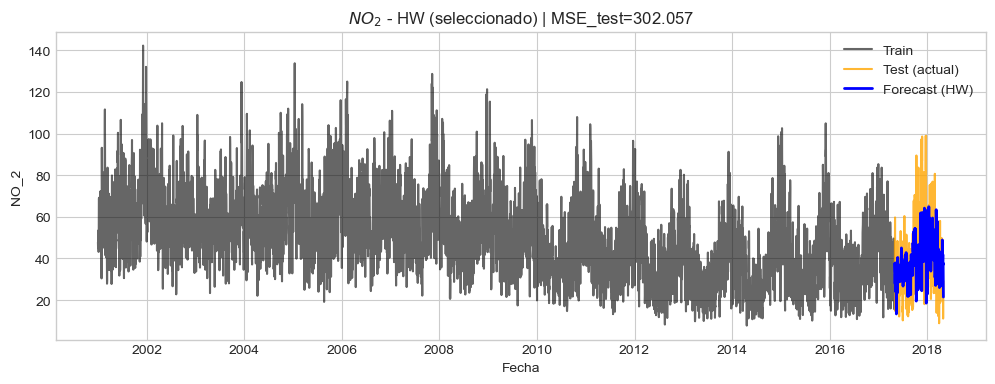


ANALIZANDO GAS: CO
Longitudes: total=6330 | train=5965 | val=0 | test=365
 -> Total de combinaciones a evaluar: 276 (se harán en paralelo con n_jobs=-1)
 -> Mejor candidato (seleccionado por MSE en TEST, modo no-validation): HW {'type': 'mul', 's': 365} {'alpha': 0.2, 'beta': 0.1, 'gamma': 0.1} MSE_test= 0.012271753454294642
 -> Métricas en TEST: MSE=0.0123 | RMSE=0.1108 | MAE=0.0789 | MAPE=21.99%


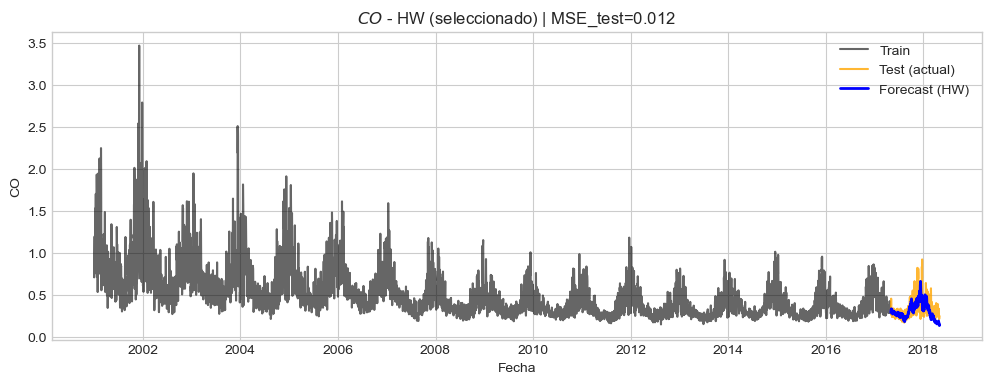

In [36]:
# -------------------------
# Almacenaremos resultados globales
# -------------------------
results_list = []   # lista de dicts => luego metrics_df

# -------------------------
# MAIN LOOP sobre cada gas
# -------------------------
for gas in contaminantes:
    print("\n" + "="*80)
    print(f"ANALIZANDO GAS: {gas}")
    print("="*80)

    # 1) verificar que la columna exista
    if gas not in df.columns:
        print(f" -> Columna {gas} no encontrada en df. Saltando.")
        continue

    # 2) remuestrear a diario y dropear NaNs (trabajamos con series diarias)
    ts = df[gas].resample('D').mean().dropna()
    if len(ts) < test_days + 10:
        print(f" -> Serie demasiado corta ({len(ts)} días). Se requiere más datos. Se omite {gas}.")
        continue

    # 3) split temporal
    if use_validation:
        train, val, test = temporal_split_train_val_test(ts, test_days, val_fraction=val_fraction)
    else:
        # si no usamos validación, entonces train_full y test
        train_full = ts.iloc[:-test_days]
        train, val, test = train_full, pd.Series(dtype=float), ts.iloc[-test_days:]

    # mostrar info
    print(f"Longitudes: total={len(ts)} | train={len(train)} | val={len(val)} | test={len(test)}")

    # 4) Construir lista de candidatos (combinaciones) para evaluar en paralelo
    #    - SES: alpha_grid
    #    - Holt: alpha_grid x beta_grid
    #    - Holt-Winters: seasonal_periods x seasonal_type x alpha x beta x gamma
    candidates = []

    # SES candidates
    for alpha in alpha_grid:
        candidates.append(('SES', {'alpha': alpha}, None))  # seasonal=None

    # Holt candidates
    for alpha in alpha_grid:
        for beta in beta_grid:
            candidates.append(('Holt', {'alpha': alpha, 'beta': beta}, None))

    # Holt-Winters candidates
    for s in seasonal_periods:
        for seasonal_type in ['add', 'mul']:
            for alpha in alpha_grid:
                for beta in beta_grid:
                    for gamma in gamma_grid:
                        # omitimos combos imposibles si s >= len(train) (no hay suficiente data)
                        if s >= len(train):
                            continue
                        seasonal = {'type': seasonal_type, 's': s}
                        params = {'alpha': alpha, 'beta': beta, 'gamma': gamma}
                        candidates.append(('HW', params, seasonal))

    # Informar cuantos candidatos hay
    print(f" -> Total de combinaciones a evaluar: {len(candidates)} (se harán en paralelo con n_jobs={n_jobs})")

    # 5) Evaluar en paralelo (cada tarea ajusta y calcula MSE en val)
    #    - Si use_validation=False, val está vacío; la función devolverá val_mse=inf,
    #      y en ese caso haremos otra lógica: ajustar sobre train_full y evaluar en test (más abajo).
    results = Parallel(n_jobs=n_jobs)(
        delayed(try_candidate)(train, val, kind, params, seasonal) for (kind, params, seasonal) in candidates
    )

    # 6) Elegir mejor según val_mse (si use_validation=True).
    #    Si use_validation=False, val_mse==inf para todos; así que elegiremos por MSE test (rehabilitaremos abajo).
    #    Primero, filtrar resultados válidos (aquellos sin error y fitted no None)
    valid_results = [r for r in results if r['fitted'] is not None]

    if use_validation:
        # seleccionar por menor val_mse
        valid_results_sorted = sorted(valid_results, key=lambda x: x['val_mse'] if x['val_mse'] is not None else np.inf)
        if len(valid_results_sorted) == 0:
            print(" -> No se ajustó ningún candidato correctamente en validación. Se omite gas.")
            continue
        best = valid_results_sorted[0]
        print(" -> Mejor candidato (por MSE en validation):", best['kind'], best['seasonal'], best['params'], "MSE_val=", best['val_mse'])
        # reentrenar el mejor modelo sobre train_full (train+val) antes de evaluar en test
        train_full = pd.concat([train, val]) if len(val) > 0 else train
        # Reajustamos con la especificación de best (para asegurar fit sobre train_full)
        kind = best['kind']; params = best['params']; seasonal = best['seasonal']
        try:
            if kind == 'SES':
                model_final = SimpleExpSmoothing(train_full, initialization_method="estimated")
                if params.get('alpha') is None:
                    fitted_final = model_final.fit(optimized=True)
                else:
                    fitted_final = model_final.fit(smoothing_level=params['alpha'], optimized=False)
            elif kind == 'Holt':
                model_final = Holt(train_full, initialization_method="estimated")
                if params.get('beta') is None:
                    if params.get('alpha') is None:
                        fitted_final = model_final.fit(optimized=True)
                    else:
                        fitted_final = model_final.fit(smoothing_level=params['alpha'], optimized=True)
                else:
                    fitted_final = model_final.fit(smoothing_level=params.get('alpha'), smoothing_slope=params.get('beta'), optimized=False)
            else:  # HW
                s = seasonal['s']; stype = seasonal['type']
                model_final = ExponentialSmoothing(train_full, trend='add', seasonal=stype, seasonal_periods=s, initialization_method="estimated")
                # si algun parámetro es None -> optimized True
                if (params.get('alpha') is None) or (params.get('beta') is None) or (params.get('gamma') is None):
                    fitted_final = model_final.fit(smoothing_level=params.get('alpha'),
                                                   smoothing_slope=params.get('beta'),
                                                   smoothing_seasonal=params.get('gamma'),
                                                   optimized=True)
                else:
                    fitted_final = model_final.fit(smoothing_level=params.get('alpha'),
                                                   smoothing_slope=params.get('beta'),
                                                   smoothing_seasonal=params.get('gamma'),
                                                   optimized=False)
        except Exception as e:
            print(" -> Reentrenamiento final falló:", e)
            # fallback: usar el fitted obtenido durante el grid (si existe)
            fitted_final = best['fitted']
    else:
        # Sin validación: aquí seleccionamos usando evaluación directa sobre TEST.
        # Para ello, reentrenamos cada candidato (ya que fitted fue hecho sólo sobre 'train') sobre train_full
        # y evaluamos en test; esto permite elegir por performance en test (si es lo que preferís).
        # Nota: esto NO es recomendado para model selection (filtrado de test), pero el usuario pidió opción sin val.
        train_full = train  # en este modo train==train_full por diseño más arriba
        test_vals = test.values
        candidates_eval = []

        def fit_and_eval_on_test(candidate):
            kind, params, seasonal = candidate
            try:
                # reproducir ajuste sobre train_full
                if kind == 'SES':
                    model = SimpleExpSmoothing(train_full, initialization_method="estimated")
                    fitted = model.fit(smoothing_level=params.get('alpha'), optimized=False)
                elif kind == 'Holt':
                    model = Holt(train_full, initialization_method="estimated")
                    if params.get('beta') is None:
                        fitted = model.fit(smoothing_level=params.get('alpha'), optimized=True)
                    else:
                        fitted = model.fit(smoothing_level=params.get('alpha'), smoothing_slope=params.get('beta'), optimized=False)
                else:  # HW
                    s = seasonal['s']; stype = seasonal['type']
                    if s >= len(train_full):
                        return {'candidate': candidate, 'mse': np.inf, 'fitted': None, 'error': 'seasonal > train len'}
                    model = ExponentialSmoothing(train_full, trend='add', seasonal=stype, seasonal_periods=s, initialization_method="estimated")
                    if (params.get('alpha') is None) or (params.get('beta') is None) or (params.get('gamma') is None):
                        fitted = model.fit(smoothing_level=params.get('alpha'),
                                           smoothing_slope=params.get('beta'),
                                           smoothing_seasonal=params.get('gamma'),
                                           optimized=True)
                    else:
                        fitted = model.fit(smoothing_level=params.get('alpha'),
                                           smoothing_slope=params.get('beta'),
                                           smoothing_seasonal=params.get('gamma'),
                                           optimized=False)
                # predecir test
                try:
                    yhat = fitted.predict(start=test.index[0], end=test.index[-1])
                except Exception:
                    yhat = fitted.forecast(steps=len(test))
                    yhat = pd.Series(yhat, index=test.index)
                mask = ~np.isnan(test_vals) & ~np.isnan(yhat.values)
                if mask.sum() == 0:
                    mse_test = np.inf
                else:
                    mse_test = mean_squared_error(test_vals[mask], yhat.values[mask])
                return {'candidate': candidate, 'mse': mse_test, 'fitted': fitted}
            except Exception as e:
                return {'candidate': candidate, 'mse': np.inf, 'fitted': None, 'error': str(e)}

        # Paralelizar la evaluación sobre test
        evals = Parallel(n_jobs=n_jobs)(
            delayed(fit_and_eval_on_test)(cand) for cand in candidates
        )

        # escoger el mejor por mse sobre test
        evals_valid = [e for e in evals if e.get('fitted') is not None]
        if len(evals_valid) == 0:
            print(" -> Ningún candidato pudo ajustarse sobre train_full en modo sin validación. Se omite gas.")
            continue
        best_eval = min(evals_valid, key=lambda x: x['mse'])
        # recuperar info para reentrenar (aunque fitted ya fue entrenado sobre train_full)
        kind, params, seasonal = best_eval['candidate']
        fitted_final = best_eval['fitted']
        best = {'kind': kind, 'params': params, 'seasonal': seasonal, 'val_mse': best_eval['mse']}
        print(" -> Mejor candidato (seleccionado por MSE en TEST, modo no-validation):", kind, seasonal, params, "MSE_test=", best_eval['mse'])

    # 7) Con fitted_final listo, predecir sobre TEST y calcular métricas
    try:
        # intentamos predict con índices (más robusto)
        y_pred_test = fitted_final.predict(start=test.index[0], end=test.index[-1])
    except Exception:
        # fallback a forecast(steps)
        y_pred_test = fitted_final.forecast(steps=len(test))
        y_pred_test = pd.Series(y_pred_test, index=test.index)

    # alineamos arrays y calculamos métricas
    y_true = test.values
    y_pred = y_pred_test.values
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if mask.sum() == 0:
        print(" -> No hay pares válidos en test para calcular métricas. Se omite gas.")
        continue

    mse_val = mean_squared_error(y_true[mask], y_pred[mask])
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_true[mask], y_pred[mask])
    mape_val = mape(y_true[mask], y_pred[mask])

    print(f" -> Métricas en TEST: MSE={mse_val:.4f} | RMSE={rmse_val:.4f} | MAE={mae_val:.4f} | MAPE={mape_val:.2f}%")

    # 8) Guardar info para el resumen global (metrics_df)
    results_list.append({
        'Gas': gas,
        'Best_model': best['kind'] if isinstance(best, dict) else None,
        'Seasonal': best.get('seasonal') if isinstance(best, dict) else None,
        'Params': best.get('params') if isinstance(best, dict) else None,
        'MSE': mse_val,
        'RMSE': rmse_val,
        'MAE': mae_val,
        'MAPE (%)': mape_val
    })

    # 9) Graficar serie completa (train(+val) + test) y forecast sobre test
    plt.figure(figsize=(12,4))
    # Train (+val si existió)
    plt.plot(pd.concat([train, val]).index, pd.concat([train, val]).values, label='Train(+Val)' if len(val)>0 else 'Train', color='black', alpha=0.6)
    # Test actual
    plt.plot(test.index, test.values, label='Test (actual)', color='orange', alpha=0.8)
    # Predicción sobre test
    plt.plot(y_pred_test.index, y_pred_test.values, label=f'Forecast ({best["kind"]})', color='blue', linewidth=2)
    plt.title(f"${gas}$ - {best['kind']} (seleccionado) | MSE_test={mse_val:.3f}")
    plt.xlabel('Fecha')
    plt.ylabel(gas)
    plt.legend()
    plt.grid(True)
    plt.show()

## 5. Métricas de error en series temporales <a name="series2"></a>

Supongamos que tenemos:

**Valores reales:** $y_1, y_2, \dots, y_n$

**Valores predichos por un modelo:**  $\hat{y}_1, \hat{y}_2, \dots, \hat{y}_n$

Definimos el error de predicción para cada observación como:  

$$
e_i = y_i - \hat{y}_i
$$

Las métricas cuantifican, de distintas formas, la discrepancia entre la predicción y el valor real.

#### MSE – Mean Squared Error (Error Cuadrático Medio)

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} e_i^2
$$

**Interpretación:**  
- Calcula el promedio de los errores al cuadrado.  
- Penaliza fuertemente errores grandes debido al cuadrado.  
- Métrica clásica en optimización de modelos lineales y de suavizado exponencial porque es diferenciable, facilitando la estimación de parámetros por mínimos cuadrados.

**Ventajas:**  
- Muy utilizada en modelos estadísticos y machine learning.  
- Sensible a errores grandes, fuerza al modelo a ajustar picos y caídas pronunciadas.

**Limitaciones:**  
- Penalización de errores grandes puede sobrevalorar outliers.  
- Unidades al cuadrado de la variable, difícil de interpretar directamente en la misma escala que los datos originales.

**Ejemplo práctico:**  
Si tus errores promedio son 5 unidades, el MSE será $5^2 = 25$ (unidades al cuadrado).

#### RMSE – Root Mean Squared Error (Raíz del Error Cuadrático Medio)

$$
\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**Interpretación:**  
- Raíz cuadrada del MSE, volviendo a la misma unidad que los datos originales.  
- Permite interpretar el error promedio en la misma escala que la variable.

**Ventajas:**  
- Conserva la sensibilidad a errores grandes.  
- Más interpretable que MSE porque no está al cuadrado.

**Limitaciones:**  
- Igual que MSE, puede ser afectado por outliers.

#### MAE – Mean Absolute Error (Error Absoluto Medio)

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| = \frac{1}{n} \sum_{i=1}^{n} |e_i|
$$

**Interpretación:**  
- Promedio de la magnitud de los errores, ignorando el signo.  
- Cada error contribuye proporcionalmente, no al cuadrado.

**Ventajas:**  
- Más robusto a outliers que MSE.  
- Fácil de interpretar: promedio de cuánto nos desviamos del valor real.

**Limitaciones:**  
- No penaliza fuertemente grandes errores.  
- No es diferenciable en 0, lo que puede ser un inconveniente en algunos métodos de optimización.

#### MAPE – Mean Absolute Percentage Error (Error Porcentual Absoluto Medio)

$$
\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{|y_i|}
$$

**Interpretación:**  
- Expresa el error como porcentaje del valor real.  
- Muy útil para comparar series de diferente magnitud.

**Ventajas:**  
- Intuitivo: el error promedio en términos porcentuales.  
- Permite comparar modelos en distintas escalas.

**Limitaciones:**  
- Problemas si $y_i = 0$ (división por cero).  
- Puede sobrevalorar errores cuando los valores reales son muy pequeños.

#### Comparación resumida

| Métrica  | Sensibilidad a outliers | Unidad           | Interpretación                                               |
| -------- | ----------------------- | ---------------- | ------------------------------------------------------------ |
| **MSE**  | Alta                    | al cuadrado de y | Penaliza fuertemente errores grandes, útil para optimización |
| **RMSE** | Alta                    | misma que y      | Error promedio en la misma unidad que los datos              |
| **MAE**  | Media                   | misma que y      | Desviación promedio, robusto a outliers                      |
| **MAPE** | Variable                | %                | Error relativo promedio, útil para series comparables        |

***Por qué MSE es clave en suavizados exponenciales y ARIMA***
* Los modelos de series temporales clásicos (SES, Holt, Holt-Winters, ARIMA) suelen estimar parámetros minimizando el error cuadrático medio en el conjunto de entrenamiento o validación.
* MSE es diferenciable, lo que facilita técnicas de optimización automática.
* Penaliza los errores grandes, por lo que fuerza al modelo a capturar tanto la tendencia como las fluctuaciones importantes.

#### Nota teórica

Estas métricas reflejan distintos aspectos del error:
* MSE (Error Cuadrático Medio) → penaliza más los errores grandes.
* RMSE (Raíz del MSE) → vuelve el MSE a las unidades originales de la serie.
* MAE (Error Absoluto Medio) → mide el error promedio sin penalizar tanto valores extremos.
* MAPE (Error Porcentual Medio Absoluto) → expresa el error en porcentaje, útil para comparar gases con diferentes magnitudes.

Veamos las métricas de las series que hemos predicho. Entonces, primero debemos crear un dataframe.

In [37]:
# ---------------------------------------------
# Construcción del DataFrame final de métricas
# ---------------------------------------------
metrics_df = pd.DataFrame(results_list).set_index('Gas')
print("\nResumen final:")
print(metrics_df)


Resumen final:
     Best_model                   Seasonal  \
Gas                                          
NO_2         HW  {'type': 'add', 's': 365}   
CO           HW  {'type': 'mul', 's': 365}   

                                          Params         MSE       RMSE  \
Gas                                                                       
NO_2  {'alpha': 0.8, 'beta': None, 'gamma': 0.3}  302.056707  17.379779   
CO     {'alpha': 0.2, 'beta': 0.1, 'gamma': 0.1}    0.012272   0.110778   

            MAE   MAPE (%)  
Gas                         
NO_2  13.264412  39.988755  
CO     0.078880  21.985859  


Por último, veamos las gráficas de las métricas.

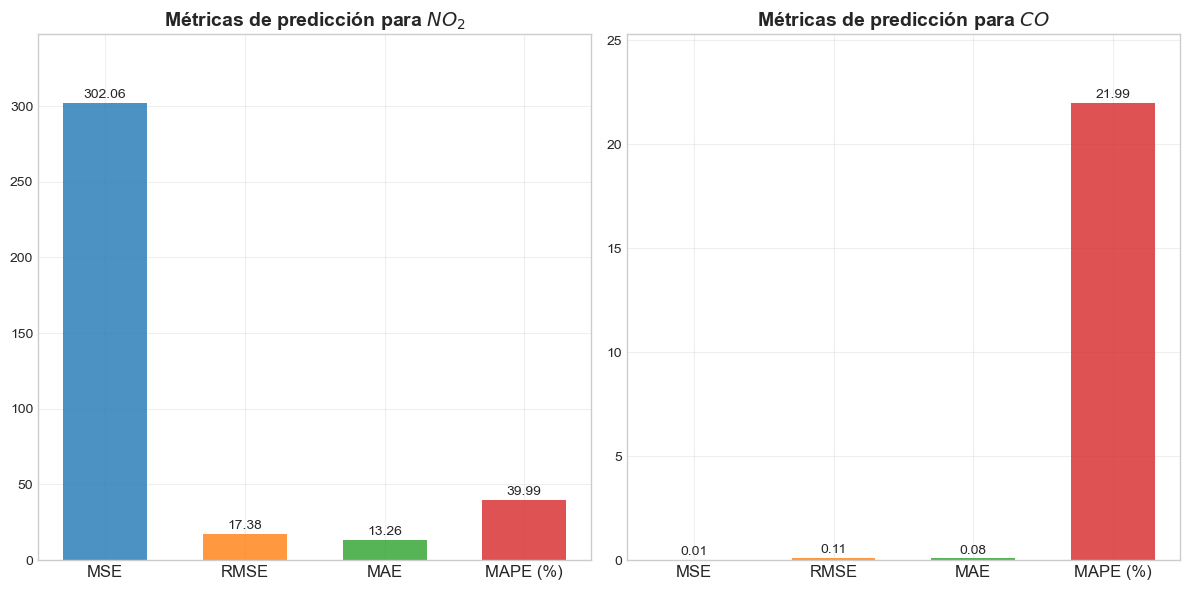

In [38]:
# ------------------
# Establecer estilo
# ------------------
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------
# Definir métricas y valores
# --------------------------
metrics_names = ['MSE', 'RMSE', 'MAE', 'MAPE (%)']
num_metrics = len(metrics_names)
width = 0.6  # ancho de barras individuales

# ------------------
# Crear figura con subplots
# ------------------
fig, axes = plt.subplots(1, len(gases), figsize=(6*len(gases), 6))  # sin sharey

if len(gases) == 1:
    axes = [axes]  # asegurar que axes sea iterable

# ------------------
# Iterar sobre cada gas y crear un gráfico
# ------------------
for ax, gas in zip(axes, gases):
    values = metrics_df.loc[gas, metrics_names].values  # valores de la fila correspondiente al gas
    x = np.arange(len(metrics_names))  # posición de cada métrica
    
    ax.bar(x, values, width, alpha=0.8, color=plt.cm.tab10.colors[:num_metrics])
    
    # Etiquetas de ejes
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, fontsize=12)
    ax.set_title(f"Métricas de predicción para ${gas}$", fontsize=14, weight='bold')
    ax.grid(True, alpha=0.3)
    
    # Ajustar escala Y automáticamente según los valores del gas
    ax.set_ylim(0, max(values)*1.15)
    
    # Mostrar valores encima de cada barra
    for i, val in enumerate(values):
        ax.text(i, val + 0.01*max(values), f"{val:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()